# Bottleneck VAE Training - 256 Latent Dimensions
Training BottleneckVAE with BottleneckEncoder and ComplexBottleneckDeconvDecoder using VAE loss with KL divergence

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import time
from tqdm.auto import tqdm
import nibabel as nib

# Runtime reload
import importlib
import models.autoencoder.bottleneck_models
importlib.reload(models.autoencoder.bottleneck_models)

from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.vae.vae_bottleneck_models import (
    BottleneckEncoder,
    ComplexBottleneckDeconvDecoder,
    BottleneckVAE,
)
from models.vae.model import VAELoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Device: cuda


## Define VAE Loss Function

In [21]:
class WeightedVAELoss(nn.Module):
    """
    Final Optimized Loss Class.
    - Fixes 3D Axis Mismatch using permute(2, 1, 0).
    - Removes weight normalization (per Luca).
    - Uses 0.1 padding for background (per Luca).
    - Implements Monotonic Beta Warmup.
    """
    def __init__(self, weight_mask_path, target_shape=None, beta_final=0.0005, warmup_steps=5000):
        super().__init__()
        
        # 1. Load the Mask
        weight_nii = nib.load(weight_mask_path)
        weight_data = torch.from_numpy(weight_nii.get_fdata()).float()
        
        # --- FIX: 3D AXIS SWAP ---
        # The mask axes were scrambled (Depth <-> Width). 
        # Permutation (2, 1, 0) fixes this to match the Brain's orientation.
        weight_data = weight_data.permute(2, 1, 0)
        
        # Add batch/channel dims: [1, 1, D, H, W]
        self.full_mask = weight_data.unsqueeze(0).unsqueeze(0)
        
        # NOTE: Removed normalization (div by mean) as requested by Luca.
        
        # Register as buffer so it moves to GPU automatically but isn't a trained parameter
        self.register_buffer('weight_mask', self.full_mask)
        
        self.beta_final = beta_final
        self.warmup_steps = warmup_steps
        self.current_step = 0
        
        print(f"✅ Loss Initialized. Mask Permuted (2,1,0). Shape: {self.full_mask.shape}")
        
    def smart_adjust_mask(self, mask, target_shape):
        """
        Adjusts mask to match the input batch size (D, H, W).
        Uses padding value 0.1 for background.
        """
        _, _, D_cur, H_cur, W_cur = mask.shape
        D_tgt, H_tgt, W_tgt = target_shape
        
        # 1. PAD if smaller
        pad_d = max(0, D_tgt - D_cur)
        pad_h = max(0, H_tgt - H_cur)
        pad_w = max(0, W_tgt - W_cur)
        
        if pad_d > 0 or pad_h > 0 or pad_w > 0:
            # Pad order for F.pad is (Last_Dim_Left, Last_Dim_Right, ... First_Dim_Back)
            # i.e. (Width, Height, Depth)
            mask = F.pad(mask, (pad_w//2, pad_w-pad_w//2, 
                                pad_h//2, pad_h-pad_h//2, 
                                pad_d//2, pad_d-pad_d//2), 
                         mode='constant', value=0.1) # Luca's Note: Pad with 0.1

        # 2. CROP if larger
        _, _, D_new, H_new, W_new = mask.shape
        d_start = (D_new - D_tgt) // 2
        h_start = (H_new - H_tgt) // 2
        w_start = (W_new - W_tgt) // 2
        
        return mask[:, :, d_start:d_start+D_tgt, h_start:h_start+H_tgt, w_start:w_start+W_tgt]
    
    def forward(self, recon_x, x, mu, log_var):
        # Ensure mask is on correct device
        if self.weight_mask.device != recon_x.device:
            self.weight_mask = self.weight_mask.to(recon_x.device)
            
        current_target_shape = recon_x.shape[2:] 
        
        # Adjust mask to current batch dimensions if needed
        if self.weight_mask.shape[2:] != current_target_shape:
            adjusted_mask = self.smart_adjust_mask(self.weight_mask, current_target_shape)
        else:
            adjusted_mask = self.weight_mask
            
        # --- Weighted Reconstruction Loss ---
        squared_error = (recon_x - x) ** 2
        weighted_error = squared_error * adjusted_mask
        recon_loss = weighted_error.mean()
        
        # --- KL Divergence ---
        kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
        kl_loss = torch.mean(kl_loss)
        
        # --- Beta Warmup ---
        # Starts at 0, linearly increases to beta_final
        if self.current_step < self.warmup_steps:
            beta = self.beta_final * (self.current_step / self.warmup_steps)
        else:
            beta = self.beta_final
            
        self.current_step += 1
        
        # Total Loss
        total_loss = recon_loss + (beta * kl_loss)
        
        return total_loss, recon_loss, kl_loss, beta

In [22]:
# Create weighted VAE loss criterion
criterion = WeightedVAELoss("data/masks/weightMatrix.nii", target_shape=(64, 128, 128))
print("Weighted VAE loss criterion created")

✅ Loss Initialized. Mask Permuted (2,1,0). Shape: torch.Size([1, 1, 91, 109, 91])
Weighted VAE loss criterion created


In [23]:
# Initialize for Step 1 of Beta Scan
criterion = WeightedVAELoss(
    weight_mask_path="data/masks/weightMatrix.nii",
    beta_final=0.00001,  # START HERE (1e-5)
    warmup_steps=5000
)

✅ Loss Initialized. Mask Permuted (2,1,0). Shape: torch.Size([1, 1, 91, 109, 91])


## Data Setup

In [6]:
root_dir = Path(".")
images_dir = root_dir / "data" / "Images"
mask_path = root_dir / "data" / "masks" / "rmask_ICV.nii"

# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
output_dir = "output/Experiments/BottleneckVAETraining"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

In [7]:
# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)
display(df.head())

# Create dataloaders
print("Creating dataloaders...")
if __name__ == '__main__':
    train_loader, val_loader = create_dataloaders(
        df, batch_size=batch_size, train_split=0.8, 
        on_demand=True, mask_path=mask_path,
        num_workers=2
    )

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...


,file_path,label
0,data/Images/PPMI_Images_Cont/100004/Reconstruc...,Control
1,data/Images/PPMI_Images_Cont/100890/Reconstruc...,Control
2,data/Images/PPMI_Images_Cont/100956/Reconstruc...,Control
3,data/Images/PPMI_Images_Cont/101039/Reconstruc...,Control
4,data/Images/PPMI_Images_Cont/101195/Reconstruc...,Control


Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## Model Setup

In [24]:
target_shape = (64, 128, 128)
latent_dim = 256

def build_vae_model(latent_dim=256):
    """Build BottleneckVAE model"""
    model = BottleneckVAE(
        BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=(1,1,1)),
        ComplexBottleneckDeconvDecoder(latent_dim=latent_dim, target_shape=target_shape),
        latent_dim=latent_dim
    )
    return model.to(device)

model = build_vae_model(latent_dim=latent_dim)
num_params = count_trainable(model)
print(f"Model Parameters: {num_params / 1e6:.2f}M")

Model Parameters: 41.34M


## Training Loop

In [25]:
def train_vae_epoch(model, train_loader, optimizer, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0
    
    pbar = tqdm(train_loader, desc="Training", leave=False)
    for batch_idx, batch in enumerate(pbar):
        data = batch['volume'].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        recon, mu, log_var = model(data)
        
        # Compute loss
        loss, recon_loss, kl_loss, beta = criterion(recon, data, mu, log_var)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()
        
        pbar.set_postfix({
            'loss': f'{loss.item():.6f}',
            'recon': f'{recon_loss.item():.6f}',
            'kl': f'{kl_loss.item():.6f}',
            'beta': f'{beta:.6f}'
        })
    
    avg_loss = total_loss / len(train_loader)
    avg_recon = total_recon / len(train_loader)
    avg_kl = total_kl / len(train_loader)
    
    return avg_loss, avg_recon, avg_kl

def validate_vae(model, val_loader, criterion, device):
    """Validate model"""
    model.eval()
    total_loss = 0
    total_recon = 0
    total_kl = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Validation", leave=False)
        for batch in pbar:
            data = batch['volume'].to(device)
            
            # Forward pass
            recon, mu, log_var = model(data)
            
            # Compute loss
            loss, recon_loss, kl_loss, beta = criterion(recon, data, mu, log_var)
            
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            
            pbar.set_postfix({
                'loss': f'{loss.item():.6f}',
                'recon': f'{recon_loss.item():.6f}',
                'kl': f'{kl_loss.item():.6f}'
            })
    
    avg_loss = total_loss / len(val_loader)
    avg_recon = total_recon / len(val_loader)
    avg_kl = total_kl / len(val_loader)
    
    return avg_loss, avg_recon, avg_kl

In [26]:
# Training configuration
num_epochs = 150
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=True
)

# Training history
train_losses = []
val_losses = []
train_recon_losses = []
train_kl_losses = []
val_recon_losses = []
val_kl_losses = []

best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 20

model_name = f"bottleneck_vae_lat{latent_dim}"
checkpoint_dir = os.path.join(output_dir, model_name)
os.makedirs(checkpoint_dir, exist_ok=True)

if __name__ == '__main__':
    print(f"Starting training for {num_epochs} epochs...")
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"\nEpoch [{epoch+1}/{num_epochs}]")
        
        # Train
        train_loss, train_recon, train_kl = train_vae_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        train_recon_losses.append(train_recon)
        train_kl_losses.append(train_kl)
        
        # Validate
        val_loss, val_recon, val_kl = validate_vae(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_recon_losses.append(val_recon)
        val_kl_losses.append(val_kl)
        
        print(f"Train Loss: {train_loss:.6f} (Recon: {train_recon:.6f}, KL: {train_kl:.6f})")
        print(f"Val Loss: {val_loss:.6f} (Recon: {val_recon:.6f}, KL: {val_kl:.6f})")
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Early stopping and checkpointing
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model
            best_model_path = os.path.join(checkpoint_dir, f"{model_name}_best.pth")
            torch.save(model.state_dict(), best_model_path)
            print(f"✓ Best model saved: {best_model_path}")
        else:
            patience_counter += 1
        
        # Save periodic checkpoint
        if (epoch + 1) % 10 == 0:
            checkpoint_path = os.path.join(checkpoint_dir, f"{model_name}_epoch{epoch+1}.pth")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"✓ Checkpoint saved: {checkpoint_path}")
        
        # Early stopping
        if patience_counter >= early_stopping_patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break
    
    elapsed_time = time.time() - start_time
    print(f"\n✓ Training completed in {elapsed_time:.1f}s")
    print(f"Best validation loss: {best_val_loss:.6f}")

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting training for 150 epochs...

Epoch [1/150]


Train Loss: 0.293360 (Recon: 0.292500, KL: 2158.598558)
Val Loss: 0.388199 (Recon: 0.275398, KL: 82942.466114)
✓ Best model saved: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_best.pth

Epoch [2/150]


Train Loss: 0.263220 (Recon: 0.262465, KL: 324.836378)
Val Loss: 0.250467 (Recon: 0.249828, KL: 225.870756)
✓ Best model saved: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_best.pth

Epoch [3/150]


Train Loss: 0.238304 (Recon: 0.238029, KL: 83.950474)
Val Loss: 0.226652 (Recon: 0.226183, KL: 108.765319)
✓ Best model saved: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_best.pth

Epoch [4/150]


...

Train Loss: 0.004532 (Recon: 0.004043, KL: 48.851419)
Val Loss: 0.004543 (Recon: 0.004069, KL: 47.367329)

Epoch [147/150]


Train Loss: 0.004514 (Recon: 0.004025, KL: 48.917229)
Val Loss: 0.004438 (Recon: 0.003947, KL: 49.026768)

Epoch [148/150]


Train Loss: 0.004492 (Recon: 0.004003, KL: 48.835235)
Val Loss: 0.004372 (Recon: 0.003914, KL: 45.887729)
✓ Best model saved: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_best.pth

Epoch [149/150]


Train Loss: 0.004521 (Recon: 0.004035, KL: 48.665814)
Val Loss: 0.004938 (Recon: 0.004459, KL: 47.930299)

Epoch [150/150]


Train Loss: 0.004533 (Recon: 0.004045, KL: 48.840859)
Val Loss: 0.004395 (Recon: 0.003911, KL: 48.428508)
✓ Checkpoint saved: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_epoch150.pth

✓ Training completed in 7725.4s
Best validation loss: 0.004372


## Results Summary

In [27]:
# Create results dataframe
results_df = pd.DataFrame({
    'Epoch': range(1, len(train_losses) + 1),
    'Train Loss': train_losses,
    'Val Loss': val_losses,
    'Train Recon': train_recon_losses,
    'Train KL': train_kl_losses,
    'Val Recon': val_recon_losses,
    'Val KL': val_kl_losses,
})

# Save results
results_path = os.path.join(checkpoint_dir, f"{model_name}_results.csv")
results_df.to_csv(results_path, index=False)
print(f"Results saved to: {results_path}")

print(results_df.tail(30))

Results saved to: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_results.csv
     Epoch  Train Loss  Val Loss  Train Recon   Train KL  Val Recon     Val KL
120    121    0.004801  0.004603     0.004321  48.032128   0.004130  47.293904
121    122    0.004797  0.004880     0.004318  47.910838   0.004402  47.785655
122    123    0.004770  0.004652     0.004285  48.502496   0.004182  46.997878
123    124    0.004721  0.004549     0.004236  48.430386   0.004085  46.476722
124    125    0.004748  0.004748     0.004267  48.108775   0.004279  46.819801
125    126    0.004693  0.004579     0.004210  48.378662   0.004116  46.325466
126    127    0.004699  0.004972     0.004218  48.094622   0.004502  47.026493
127    128    0.004729  0.004552     0.004249  48.008744   0.004084  46.783786
128    129    0.004695  0.004542     0.004213  48.188155   0.004069  47.327386
129    130    0.004670  0.004685     0.004186  48.345541   0.004226  45.963607
130    131    0.

## Visualization

Plot saved to: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_training_curves.png


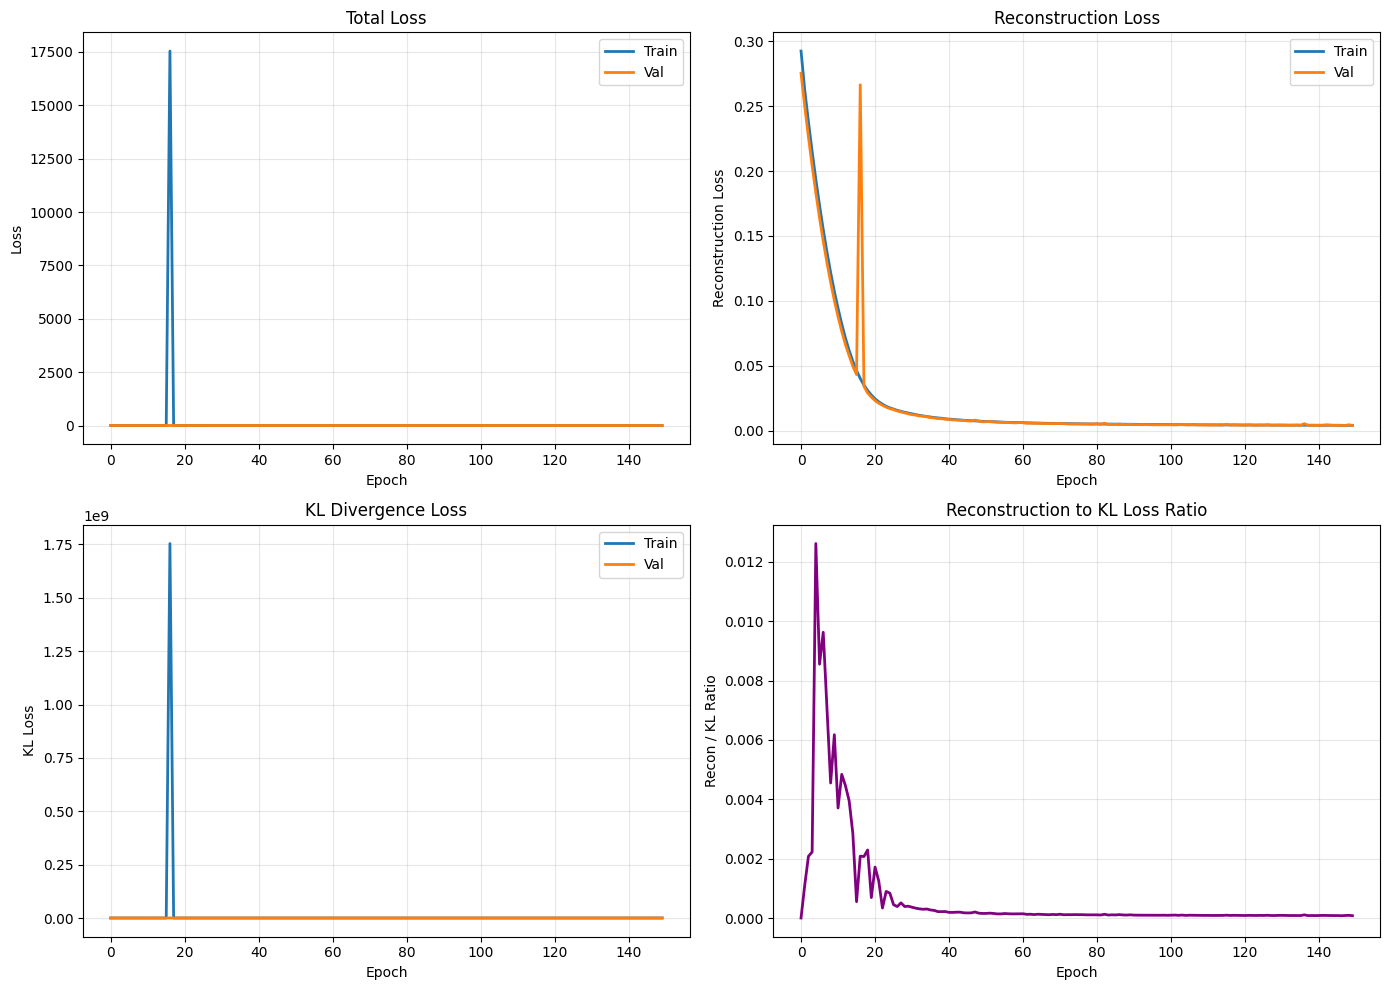

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total loss
axes[0, 0].plot(train_losses, label='Train', linewidth=2)
axes[0, 0].plot(val_losses, label='Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Reconstruction loss
axes[0, 1].plot(train_recon_losses, label='Train', linewidth=2)
axes[0, 1].plot(val_recon_losses, label='Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Reconstruction Loss')
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# KL loss
axes[1, 0].plot(train_kl_losses, label='Train', linewidth=2)
axes[1, 0].plot(val_kl_losses, label='Val', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('KL Loss')
axes[1, 0].set_title('KL Divergence Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Loss ratio
recon_kl_ratio = [r / (k + 1e-8) for r, k in zip(val_recon_losses, val_kl_losses)]
axes[1, 1].plot(recon_kl_ratio, linewidth=2, color='purple')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recon / KL Ratio')
axes[1, 1].set_title('Reconstruction to KL Loss Ratio')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(checkpoint_dir, f"{model_name}_training_curves.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")
plt.show()

In [29]:
# Load best model
best_model = build_vae_model(latent_dim=latent_dim)
best_model_path = os.path.join(checkpoint_dir, f"{model_name}_best.pth")
best_model.load_state_dict(torch.load(best_model_path))
print(f"Loaded best model from: {best_model_path}")

# Test on a few samples
best_model.eval()
with torch.no_grad():
    # 1. Get the dictionary batch
    batch = next(iter(val_loader))
    
    # 2. Extract the actual image tensor using the 'volume' key
    # (The error logs show 'volume' is one of the keys)
    test_data = batch['volume']
    
    # 3. Now you can move it to device
    test_data = test_data.to(device)
    
    # Forward pass
    recon, mu, log_var = best_model(test_data)
    
    # Compute loss
    loss, recon_loss, kl_loss, beta = criterion(recon, test_data, mu, log_var)
    
    print(f"\nTest Batch Results:")
    print(f"Total Loss: {loss.item():.6f}")
    print(f"Reconstruction Loss: {recon_loss.item():.6f}")
    print(f"KL Loss: {kl_loss.item():.6f}")
    print(f"Beta: {beta:.6f}")
    print(f"Latent Mean: {mu.mean().item():.6f}")
    print(f"Latent Std: {mu.std().item():.6f}")

Loaded best model from: output/Experiments/BottleneckVAETraining/bottleneck_vae_lat256/bottleneck_vae_lat256_best.pth

Test Batch Results:
Total Loss: 0.004697
Reconstruction Loss: 0.004238
KL Loss: 45.877007
Beta: 0.000010
Latent Mean: -0.000359
Latent Std: 0.433494


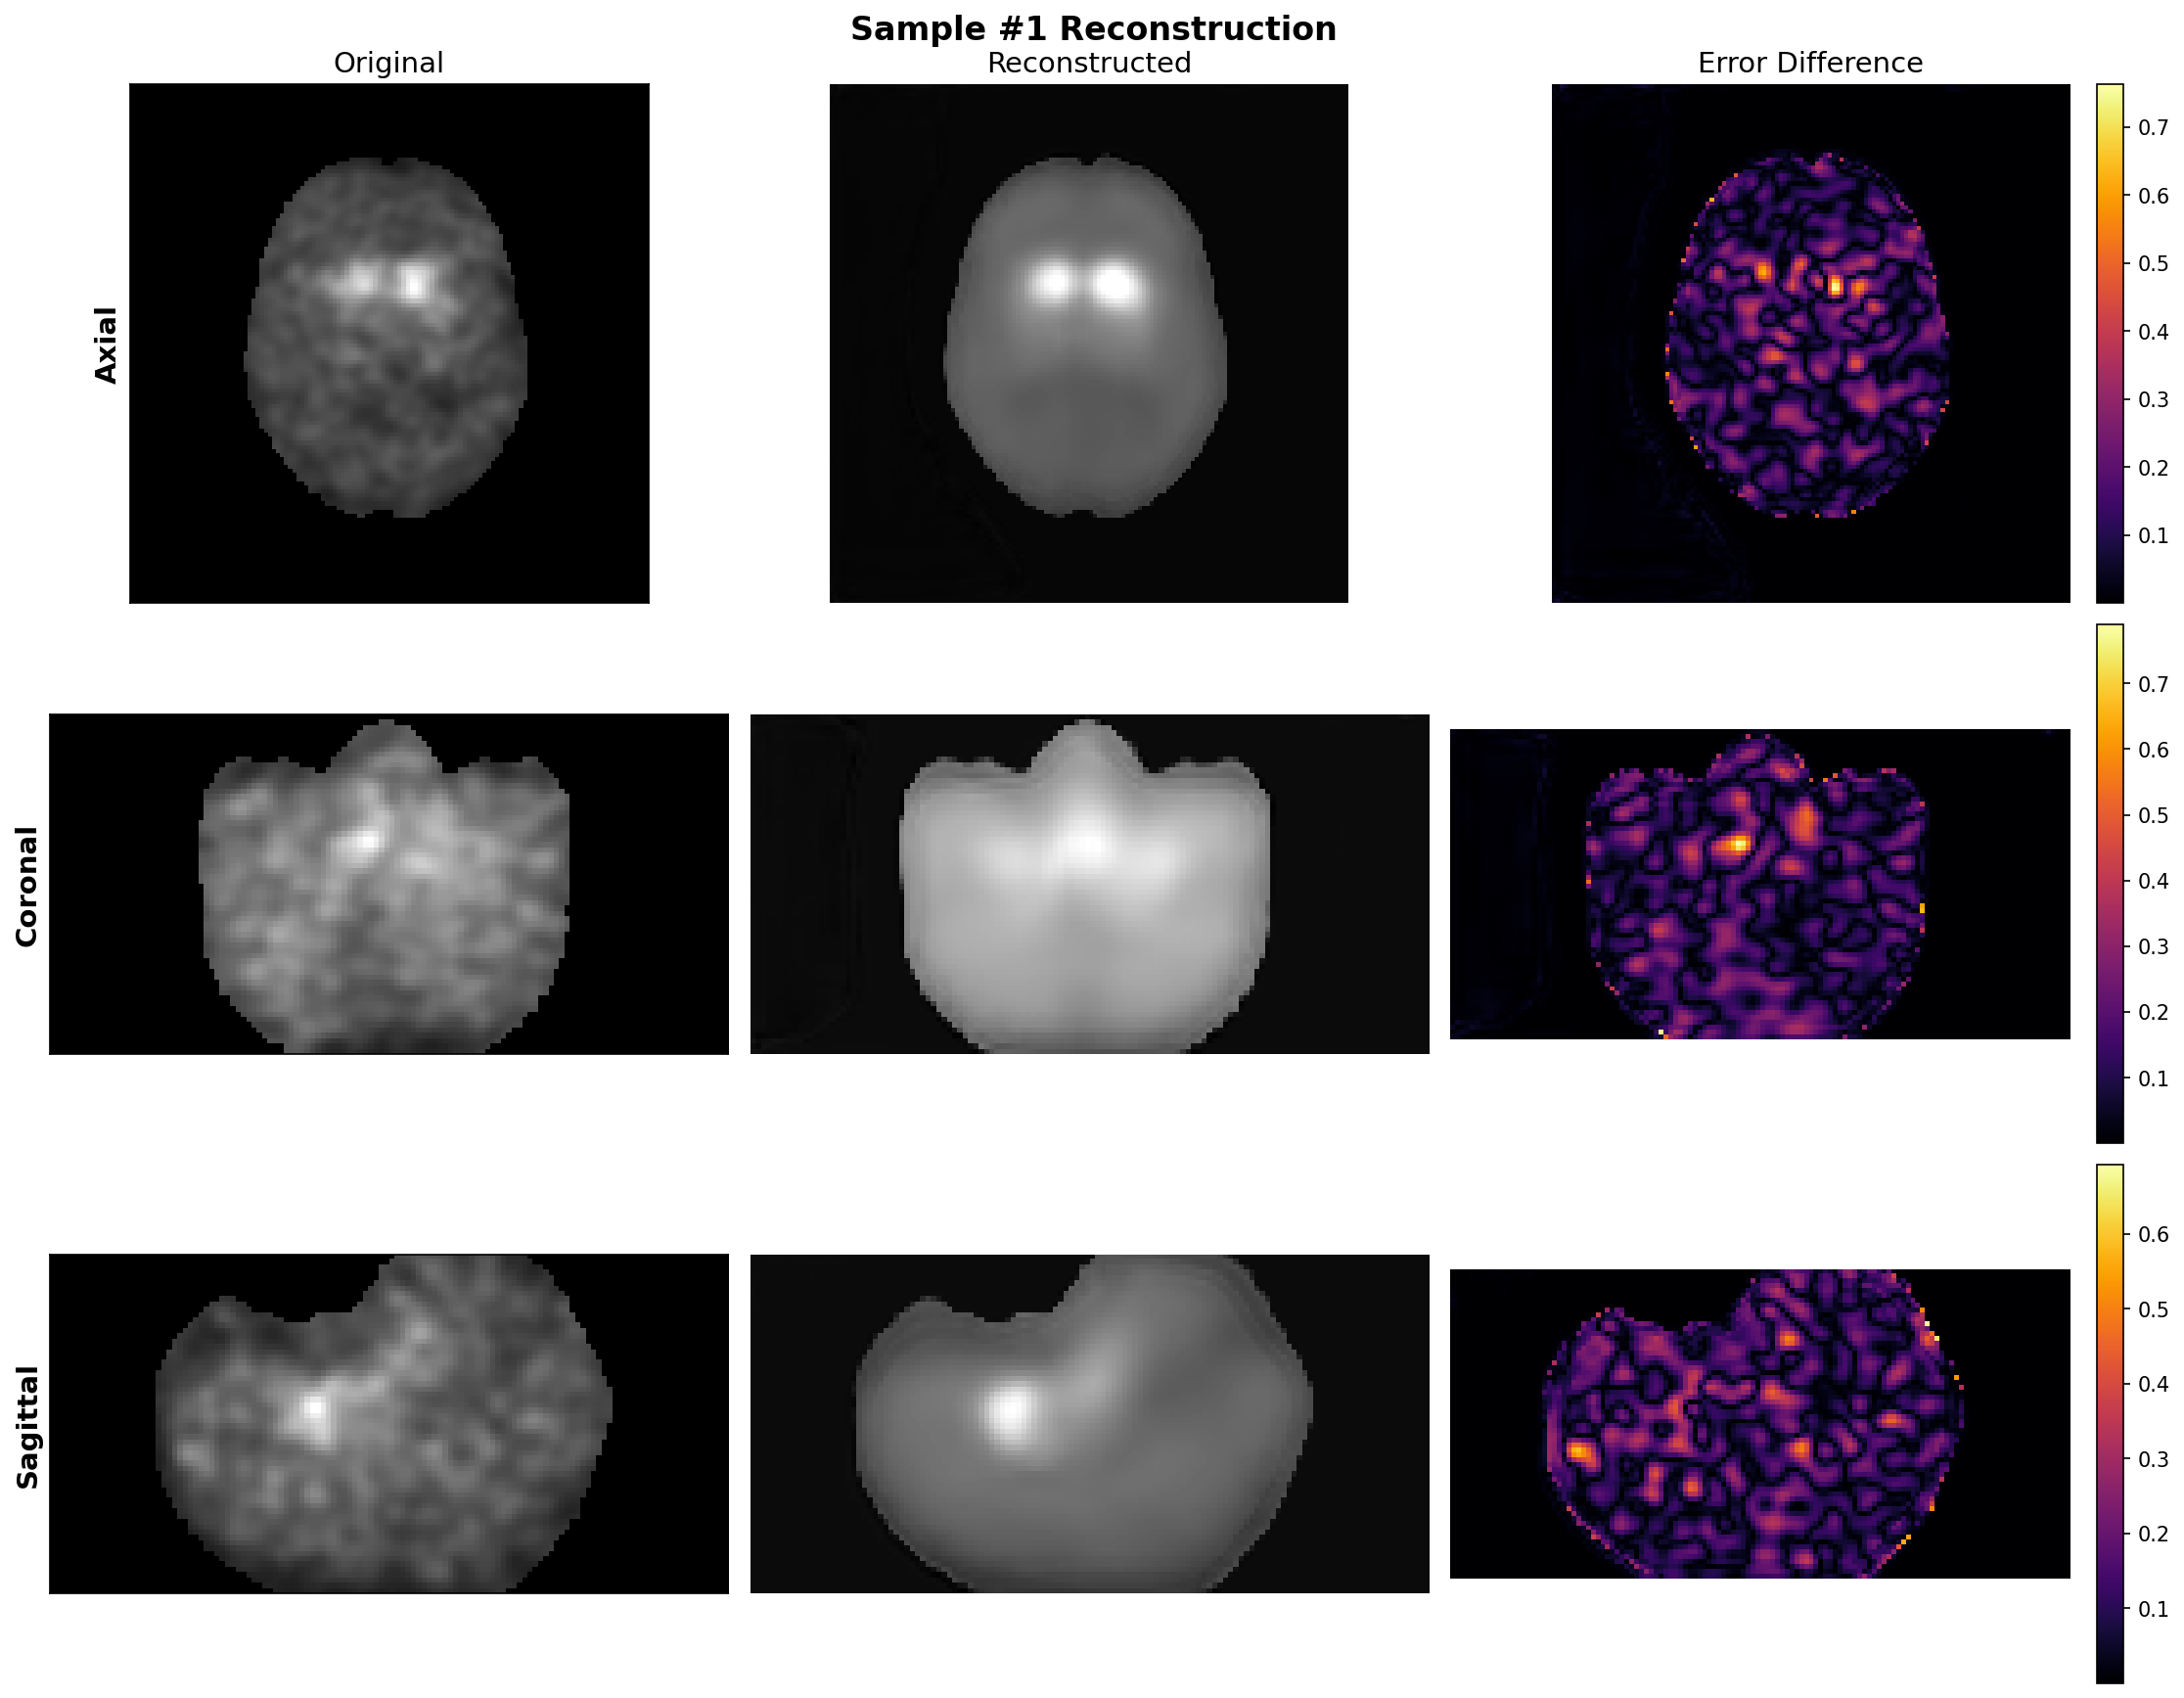

----------------------------------------------------------------------------------------------------


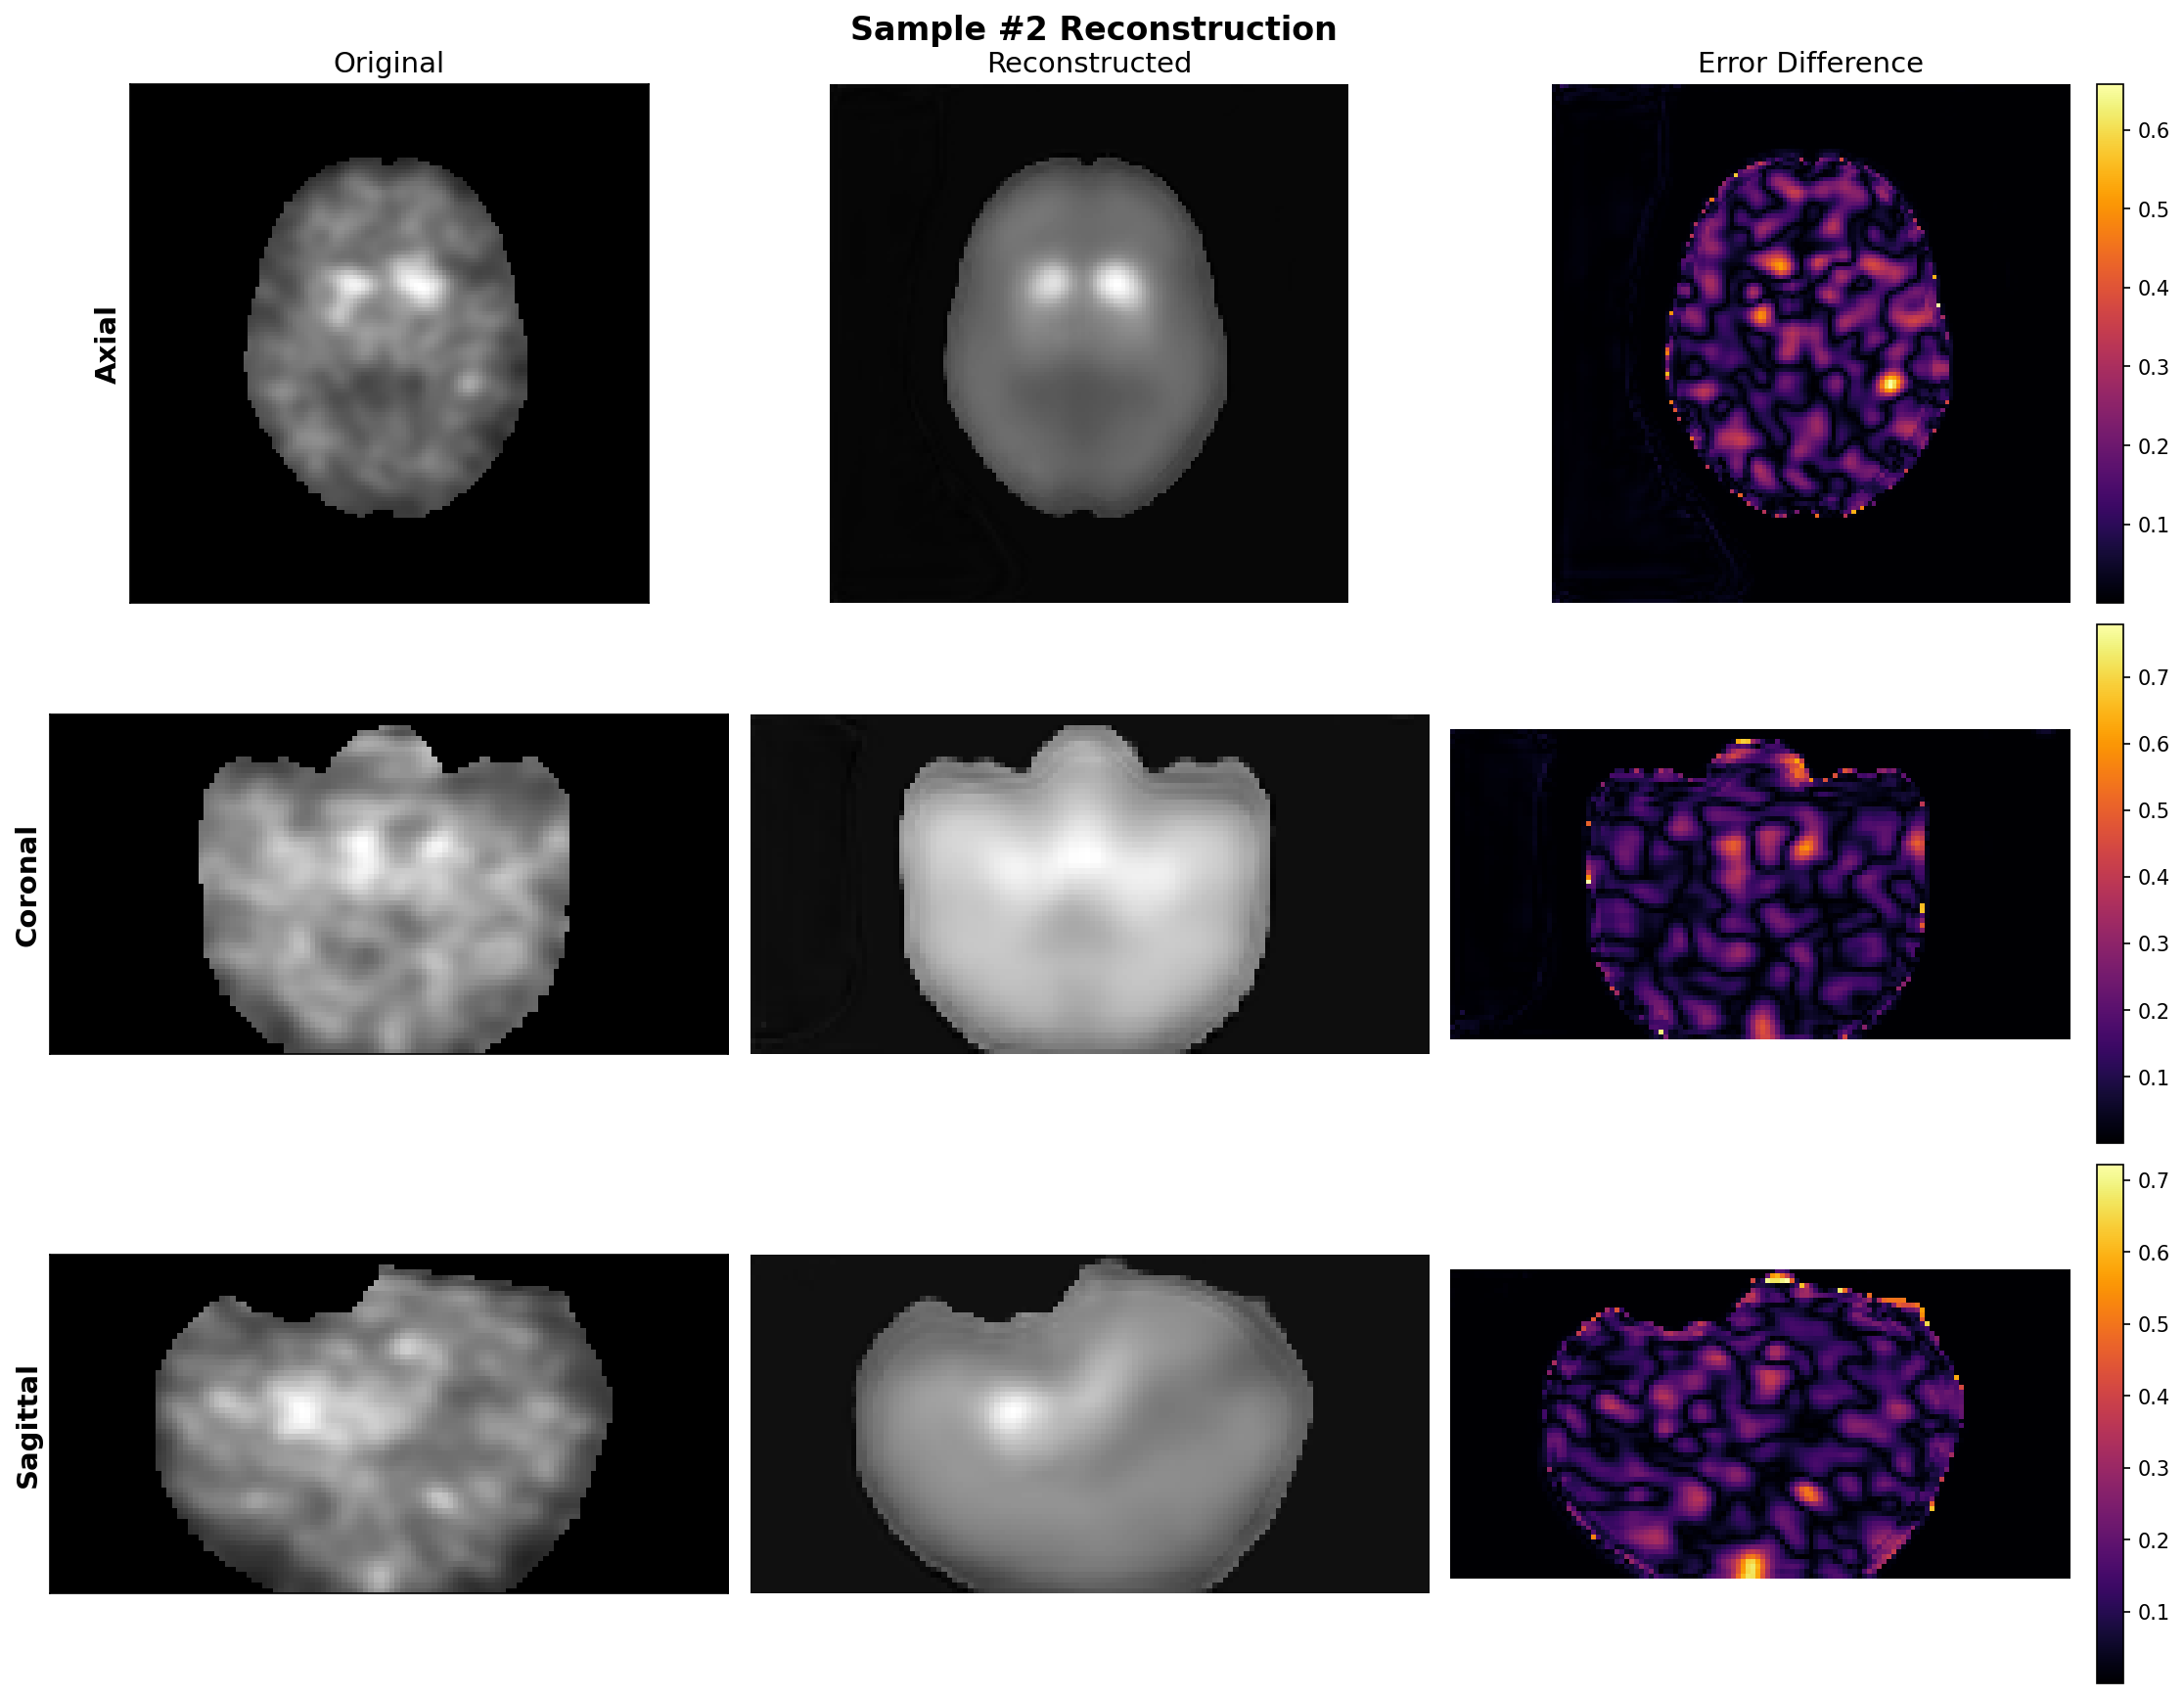

----------------------------------------------------------------------------------------------------


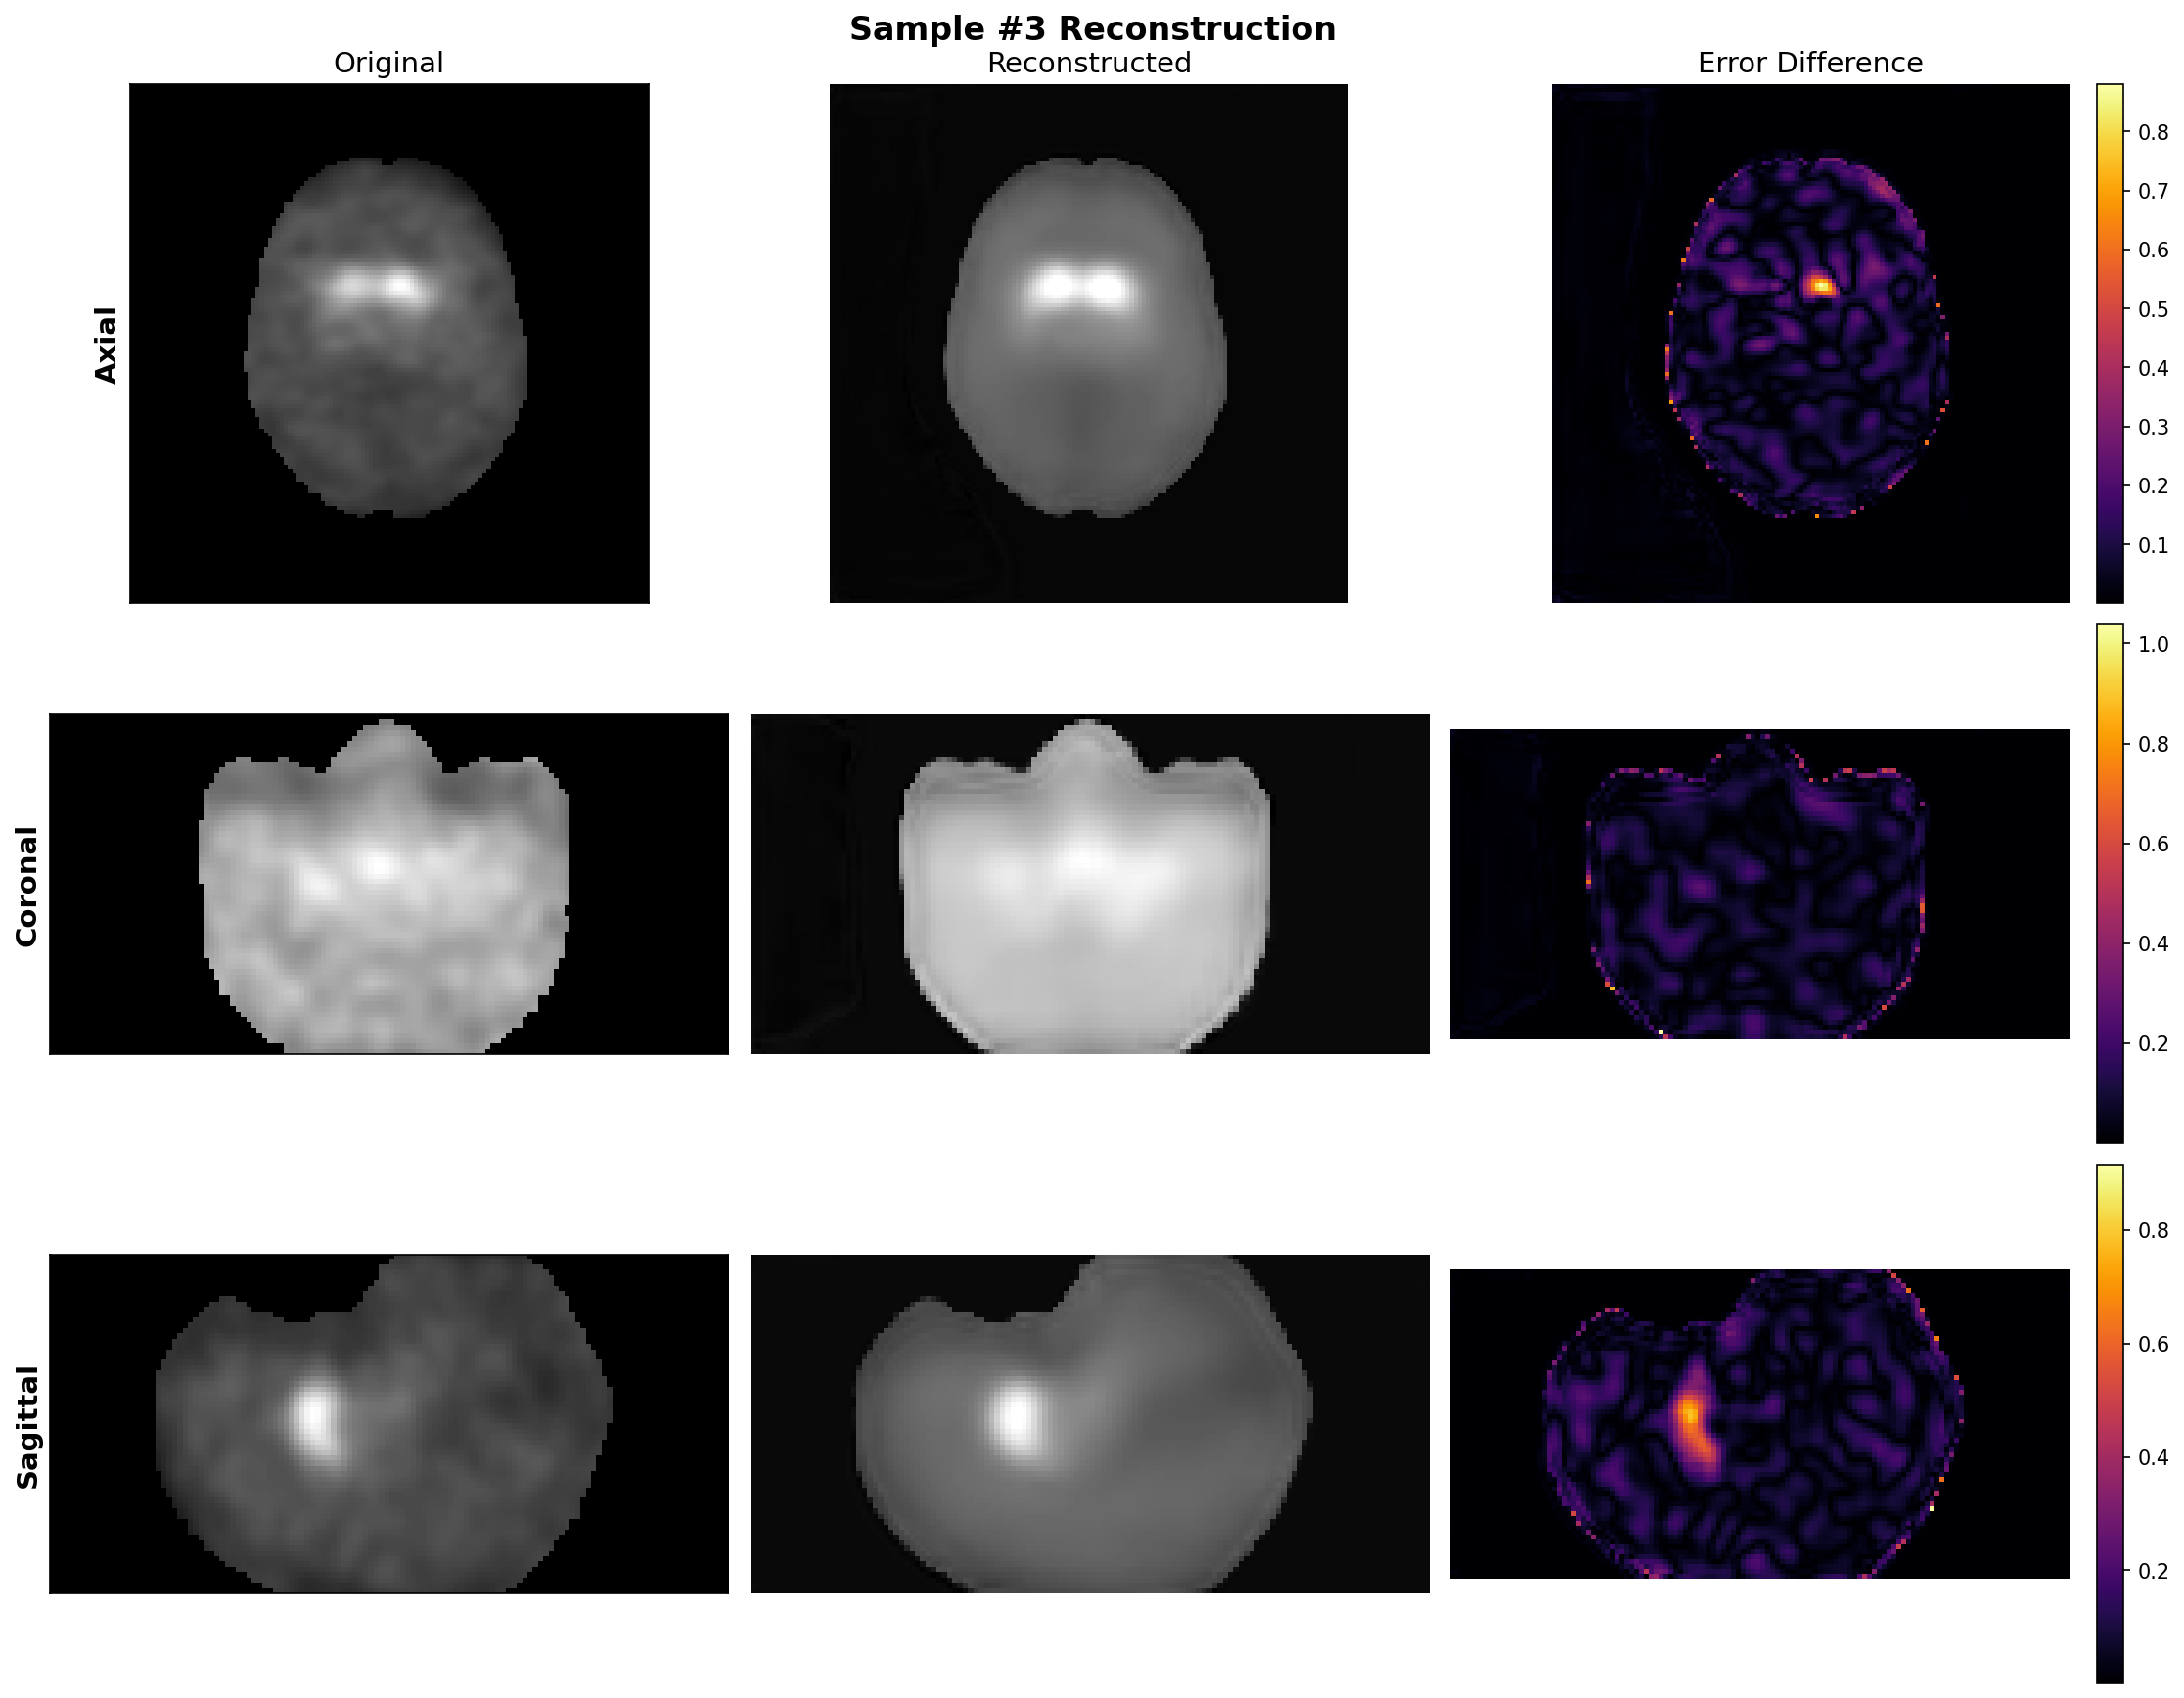

----------------------------------------------------------------------------------------------------


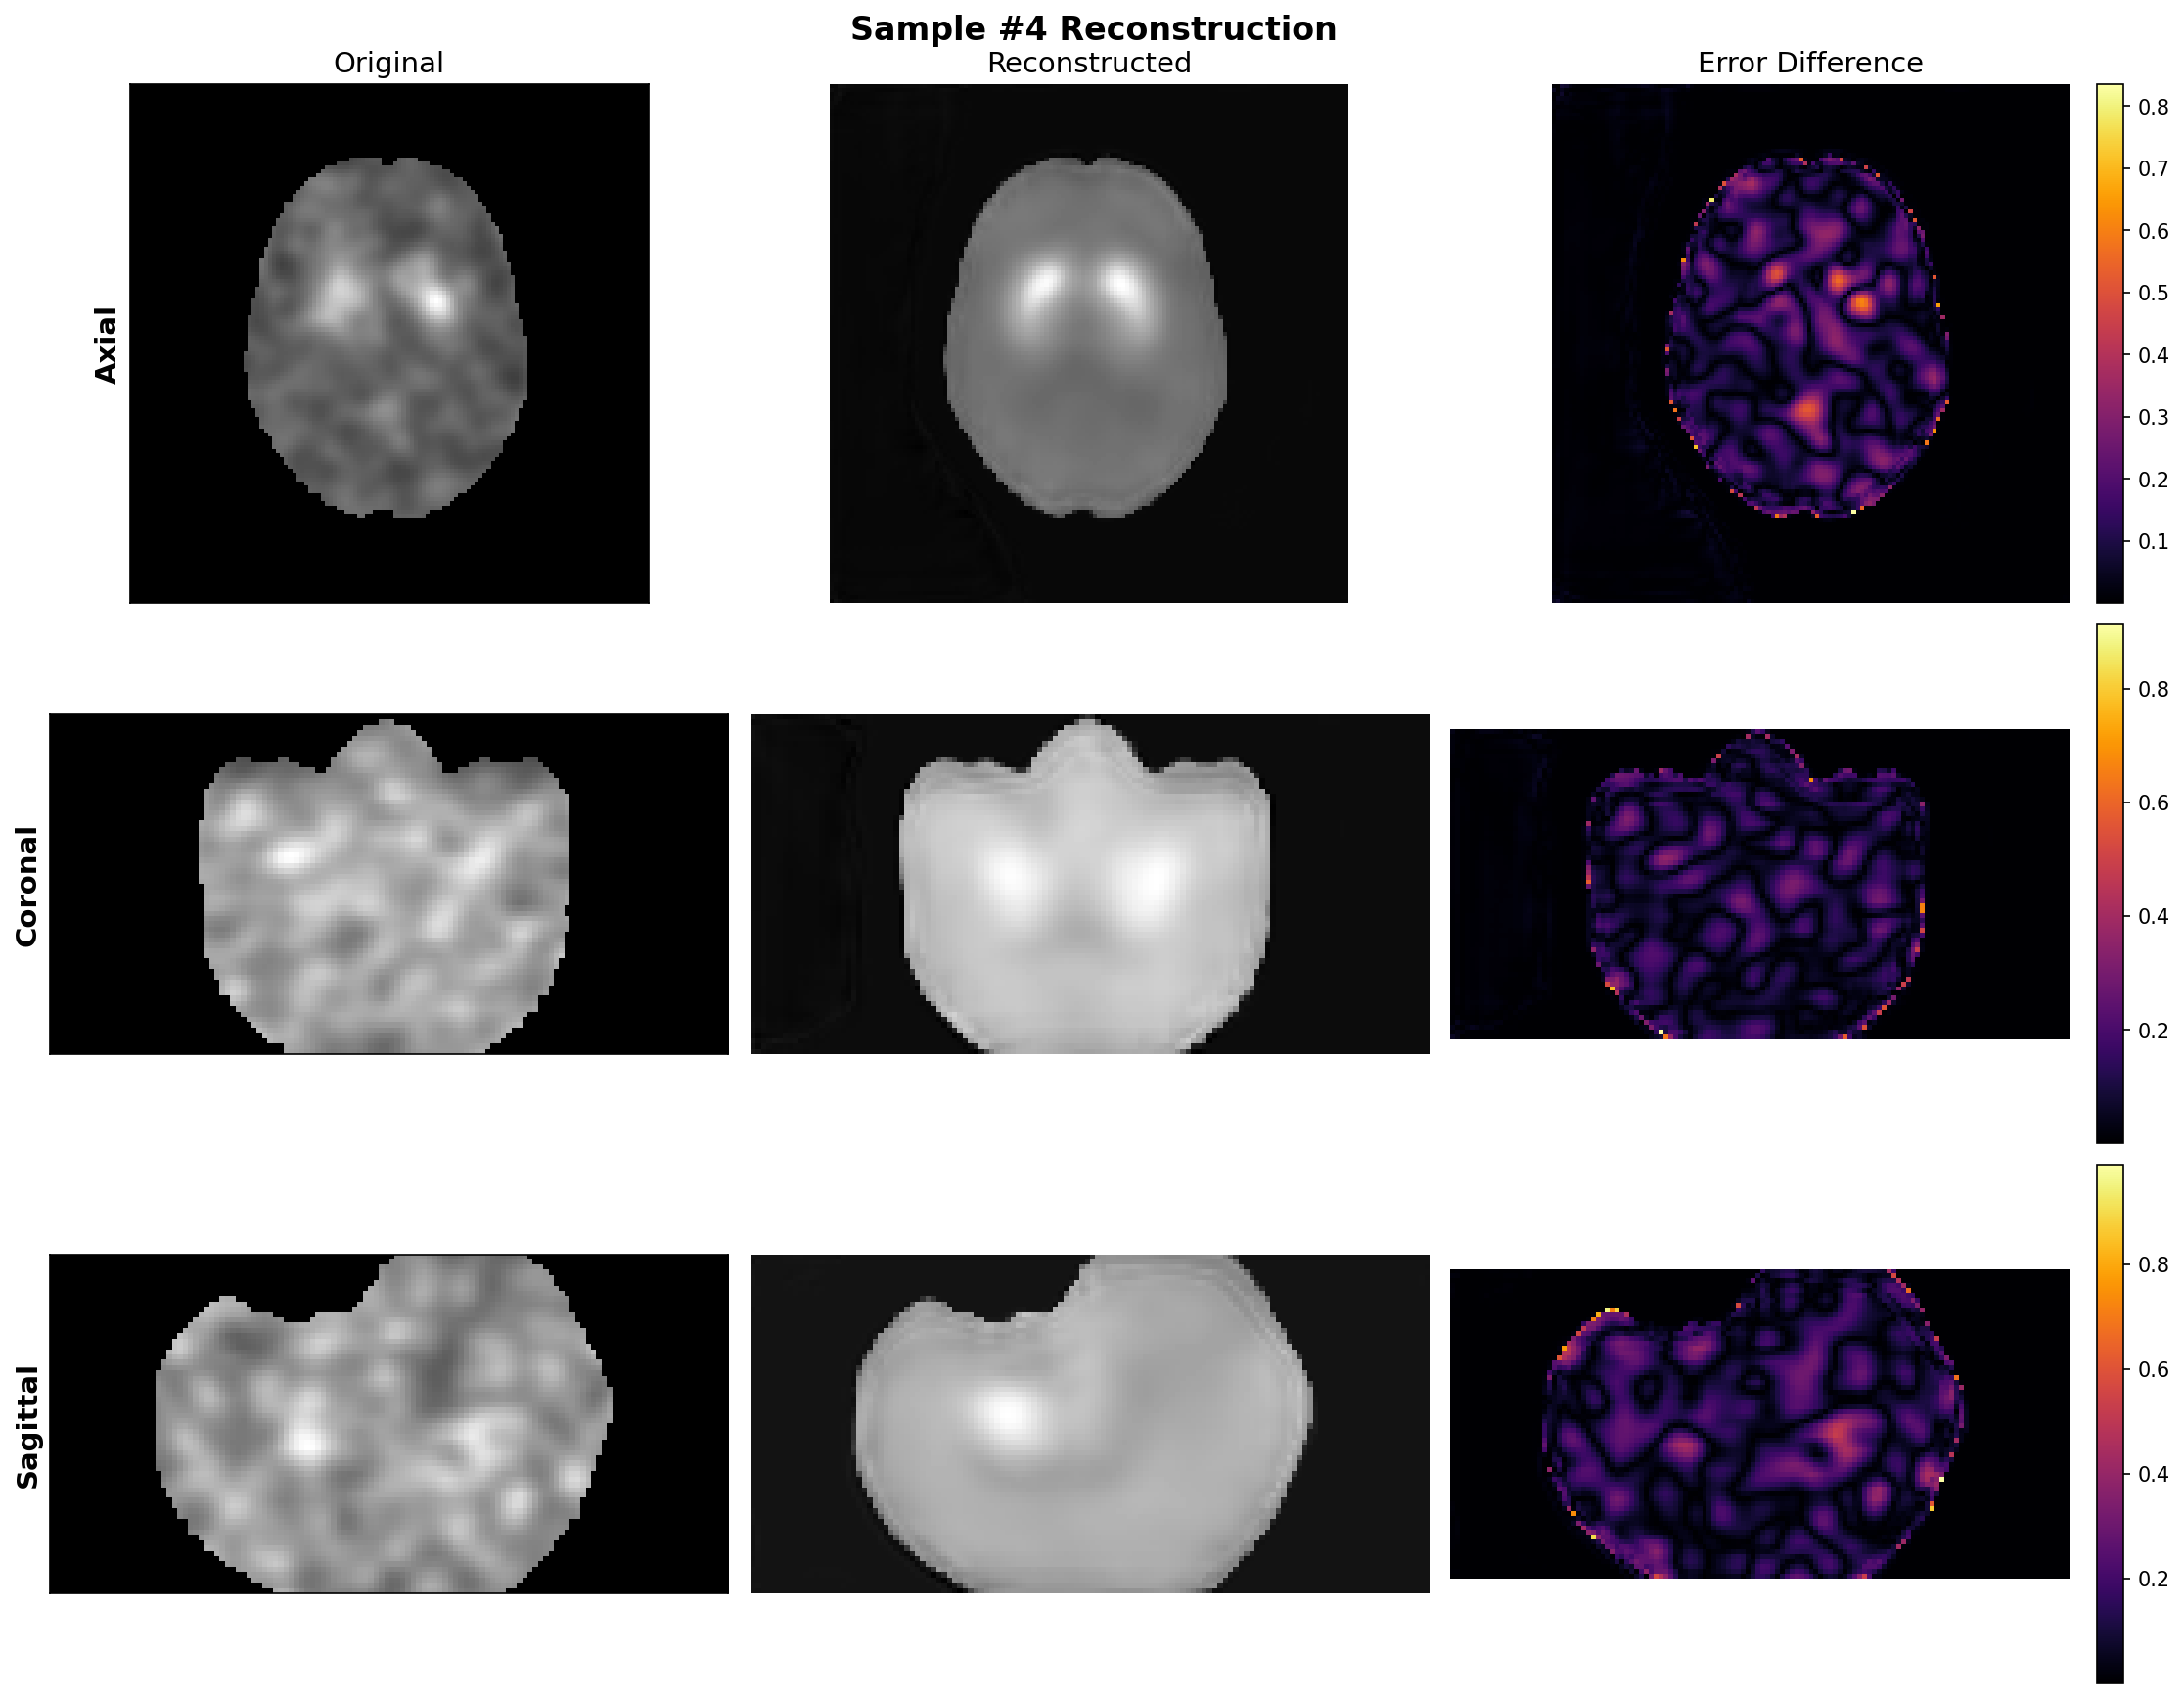

----------------------------------------------------------------------------------------------------


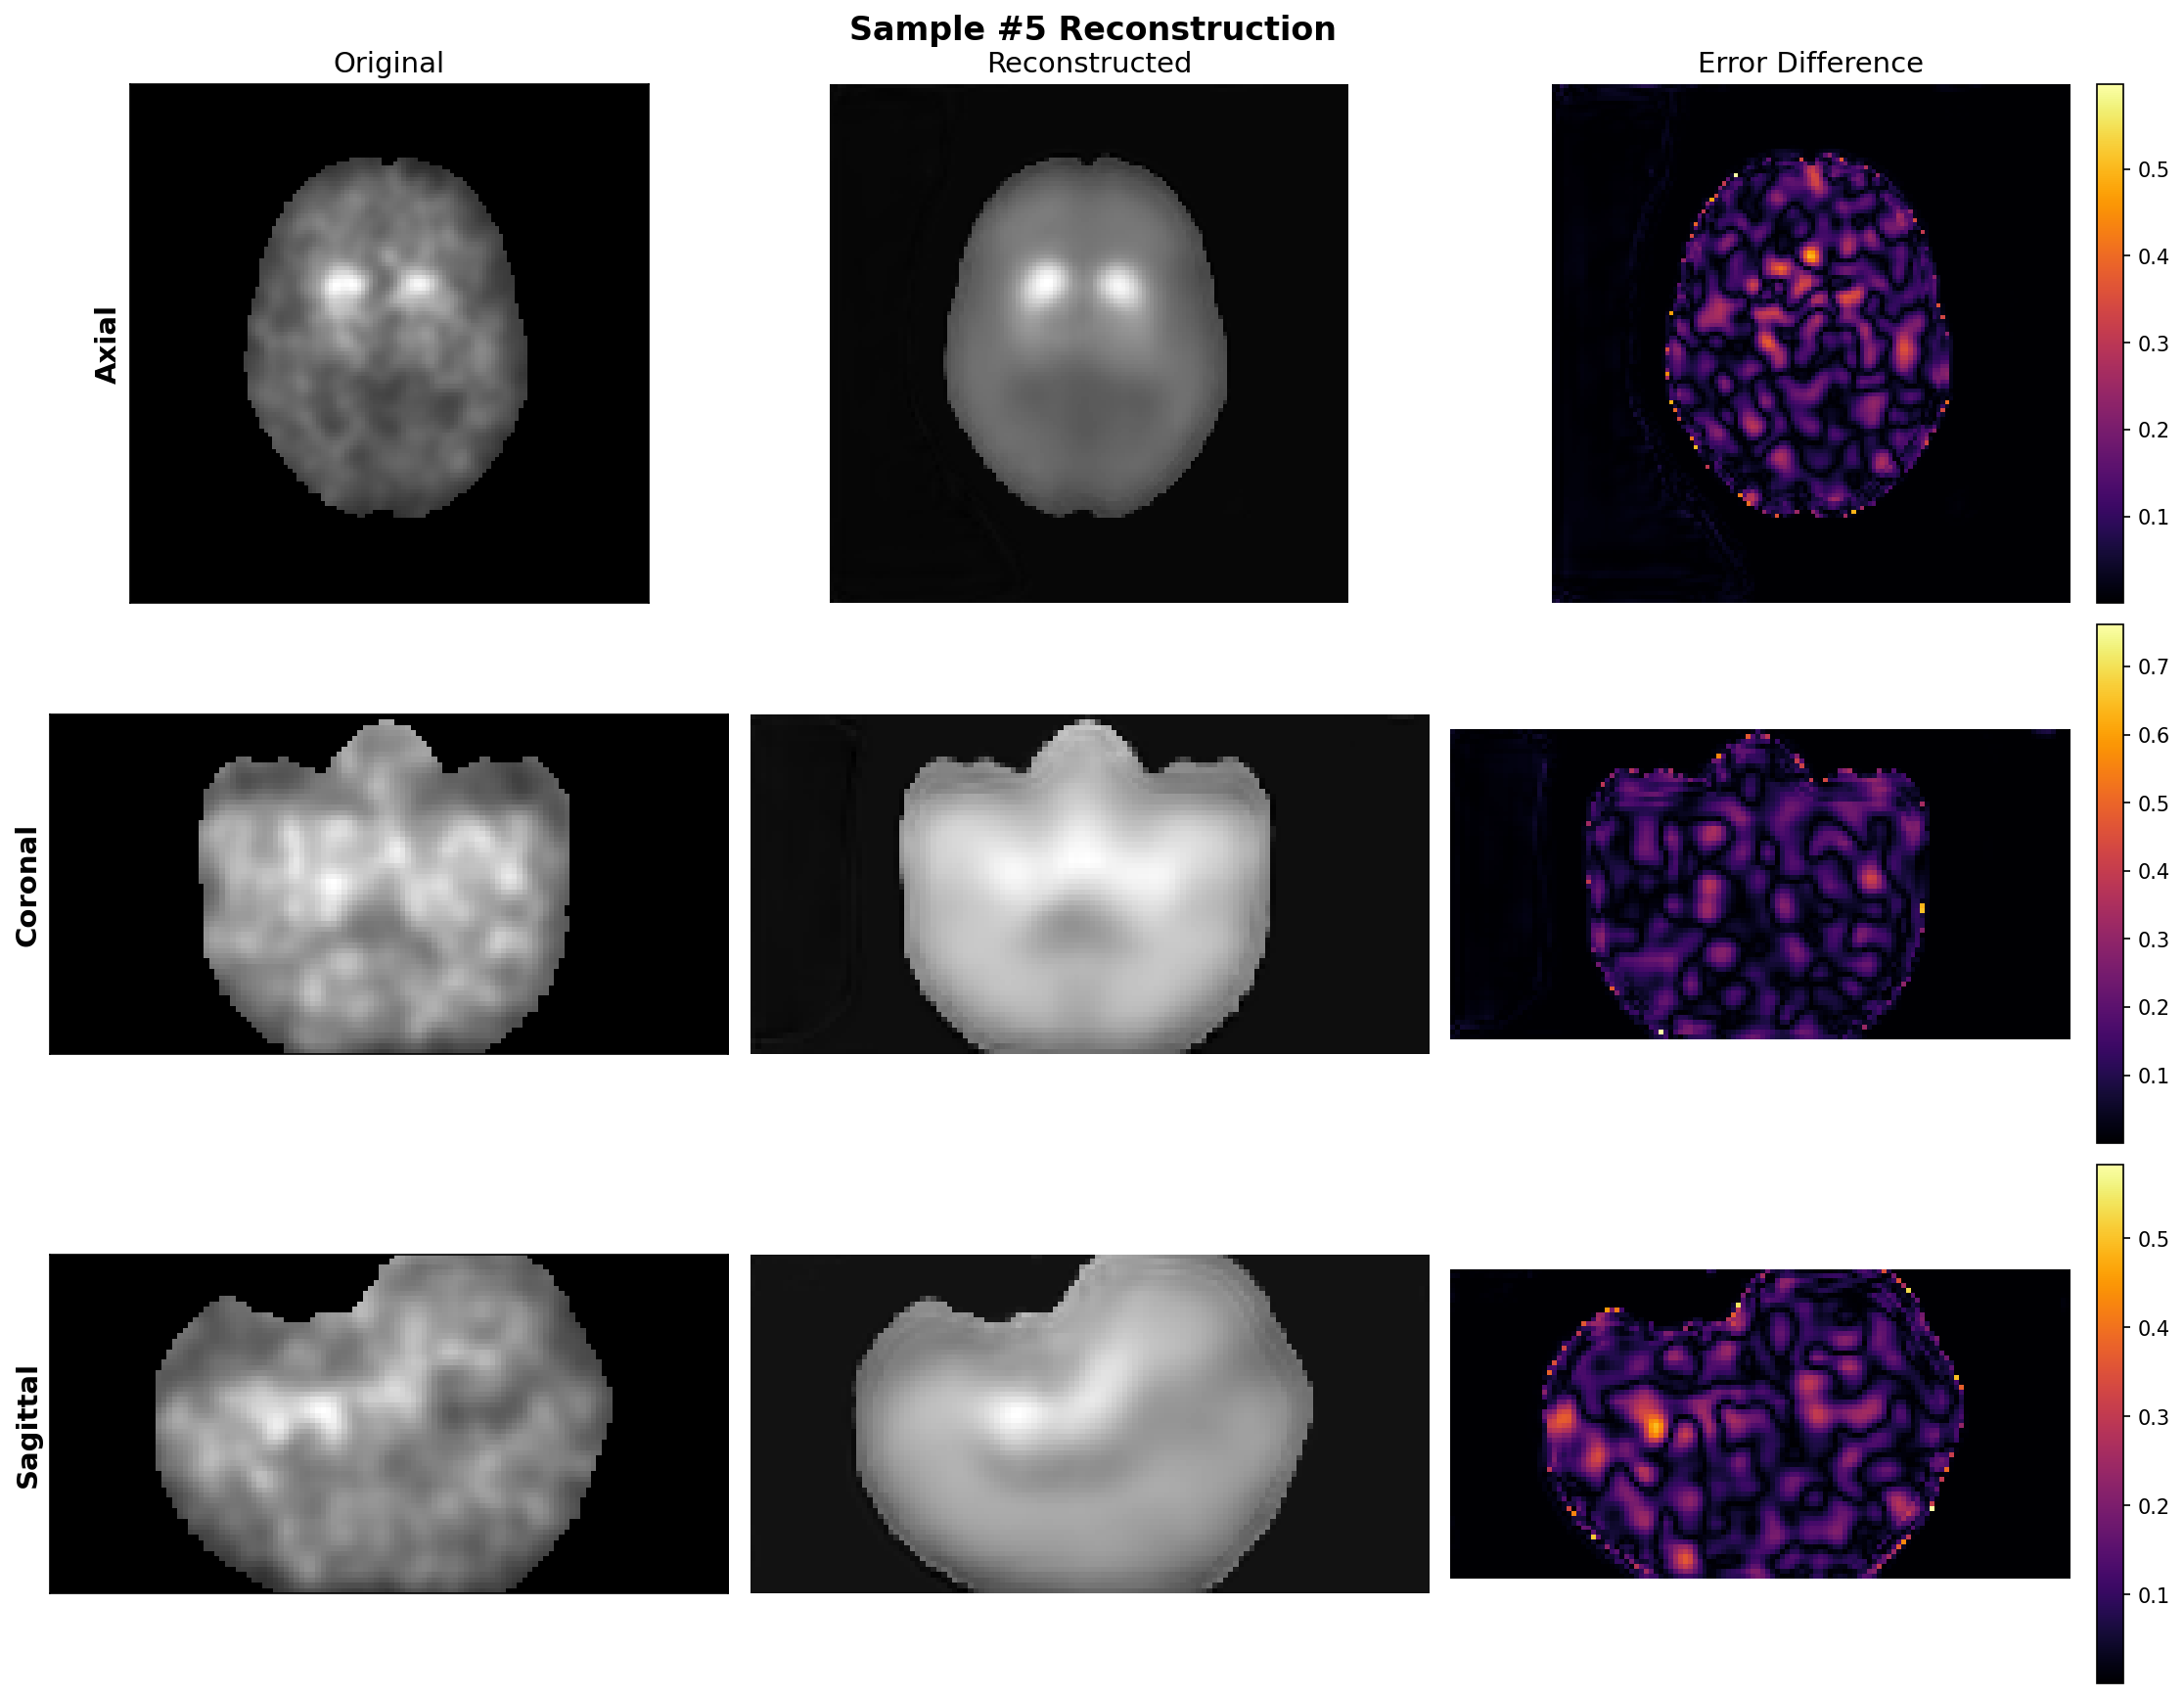

----------------------------------------------------------------------------------------------------


In [30]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Settings for large, clear plots
plt.rcParams['figure.figsize'] = [15, 12] 
plt.rcParams['figure.dpi'] = 150

# --- Step 1: Collect 5 Samples ---
num_samples_needed = 5
collected_images = []

# Iterate through loader until we have enough images
iter_loader = iter(val_loader)
while len(collected_images) < num_samples_needed:
    try:
        batch = next(iter_loader)
        # Check if batch is dict or tuple and extract volume
        imgs = batch['volume'] if isinstance(batch, dict) else batch[0]
        collected_images.extend(imgs)
    except StopIteration:
        break # Stop if dataset is exhausted

# Stack and select exactly 5
if len(collected_images) < num_samples_needed:
    print(f"Warning: Only found {len(collected_images)} samples.")
    num_samples_needed = len(collected_images)

sample_data = torch.stack(collected_images[:num_samples_needed]).to(device)

# --- Step 2: Run Inference ---
best_model.eval()
with torch.no_grad():
    recons, _, _ = best_model(sample_data)

# --- Step 3: Visualization Loop ---
# Define slices (Depth, Height, Width)
slices_indices = {
    'Axial': (0, 32),    # dim 0
    'Coronal': (1, 64),  # dim 1
    'Sagittal': (2, 64)  # dim 2
}
views = ['Axial', 'Coronal', 'Sagittal']

def get_slice(data, dim, idx):
    if dim == 0: return data[idx, :, :]
    if dim == 1: return data[:, idx, :]
    if dim == 2: return data[:, :, idx]

# Loop through each sample and create a separate figure
for i in range(num_samples_needed):
    
    # Extract single sample (CPU numpy)
    orig_np = sample_data[i, 0].cpu().numpy()
    recon_np = recons[i, 0].cpu().numpy()
    
    # Create a new Figure for this sample
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    plt.suptitle(f"Sample #{i+1} Reconstruction", fontsize=16, weight='bold', y=0.96)
    
    for row_idx, view_name in enumerate(views):
        dim_idx, slice_idx = slices_indices[view_name]
        
        # Get slices
        orig_slice = get_slice(orig_np, dim_idx, slice_idx)
        recon_slice = get_slice(recon_np, dim_idx, slice_idx)
        error_slice = np.abs(orig_slice - recon_slice)
        
        # Column 1: Original
        axes[row_idx, 0].imshow(orig_slice, cmap='gray')
        axes[row_idx, 0].set_ylabel(view_name, fontsize=14, weight='bold') # Label the row
        if row_idx == 0: axes[row_idx, 0].set_title("Original", fontsize=14)
        axes[row_idx, 0].set_xticks([])
        axes[row_idx, 0].set_yticks([])

        # Column 2: Reconstructed
        axes[row_idx, 1].imshow(recon_slice, cmap='gray')
        if row_idx == 0: axes[row_idx, 1].set_title("Reconstructed", fontsize=14)
        axes[row_idx, 1].axis('off')

        # Column 3: Error
        im = axes[row_idx, 2].imshow(error_slice, cmap='inferno')
        if row_idx == 0: axes[row_idx, 2].set_title("Error Difference", fontsize=14)
        axes[row_idx, 2].axis('off')
        
        # Add a colorbar specifically for the error plot
        plt.colorbar(im, ax=axes[row_idx, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) # Make room for main title
    plt.show()
    print("-" * 100) # Separator line

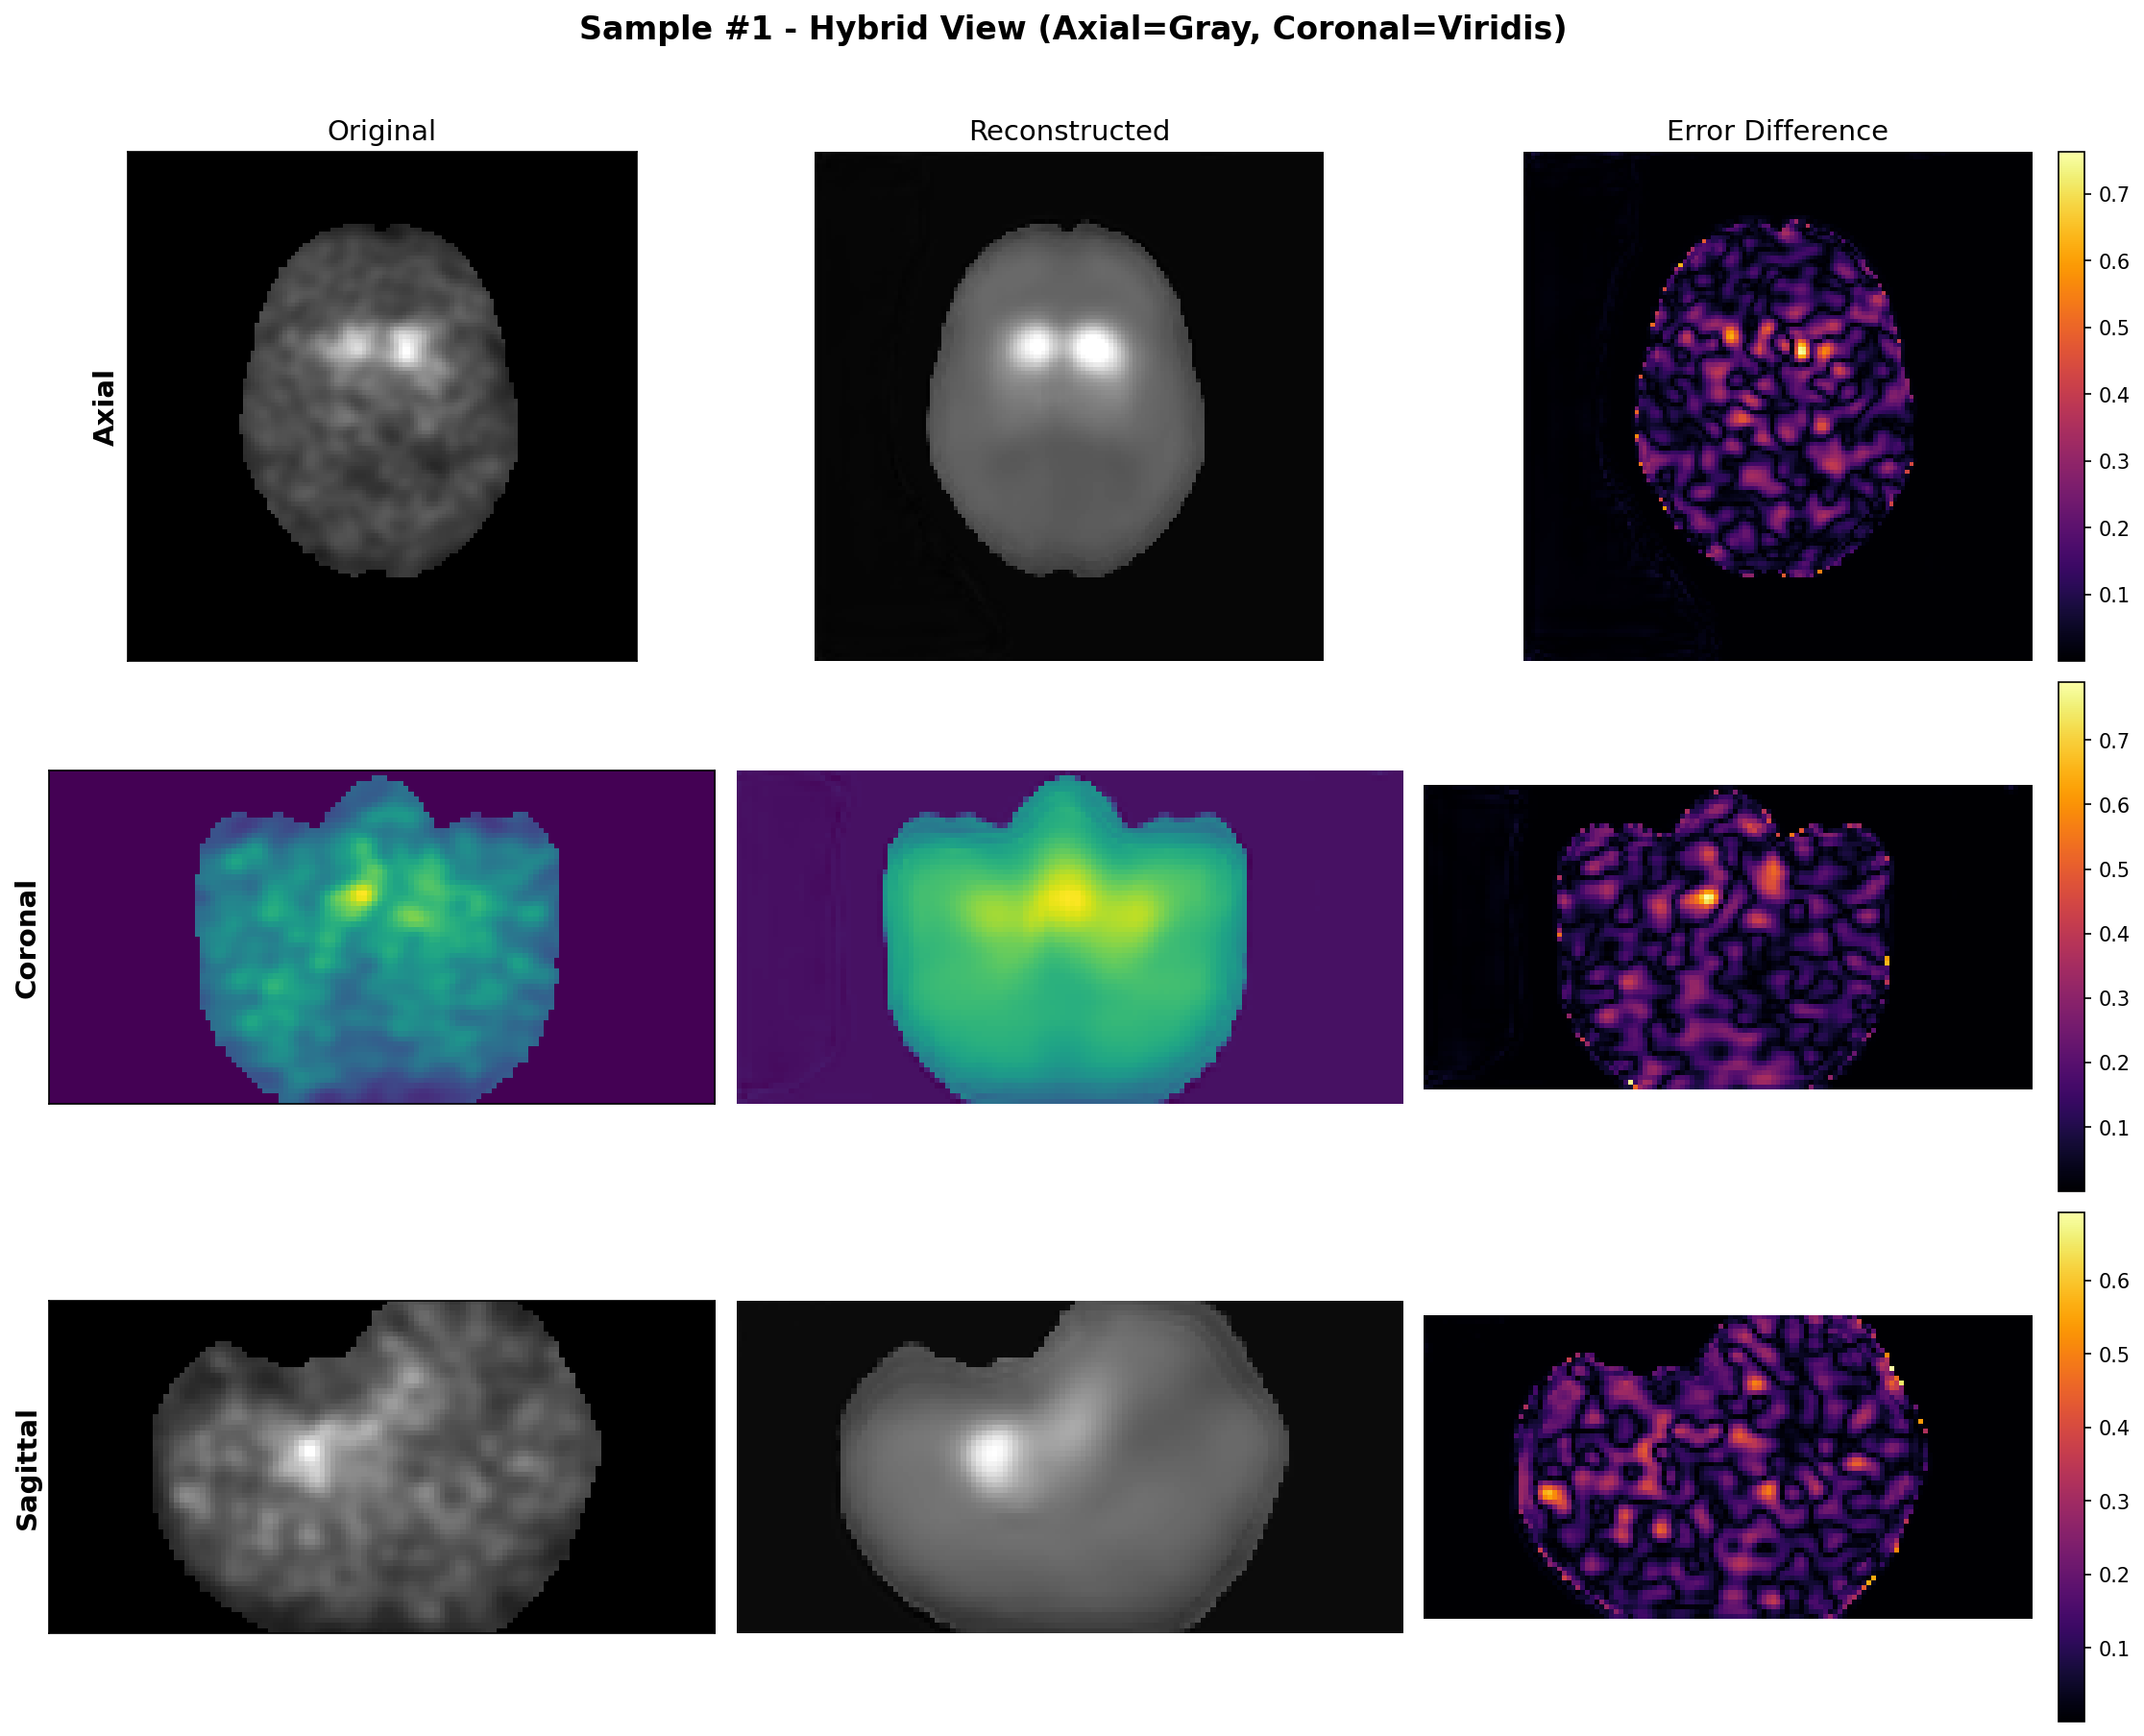

----------------------------------------------------------------------------------------------------


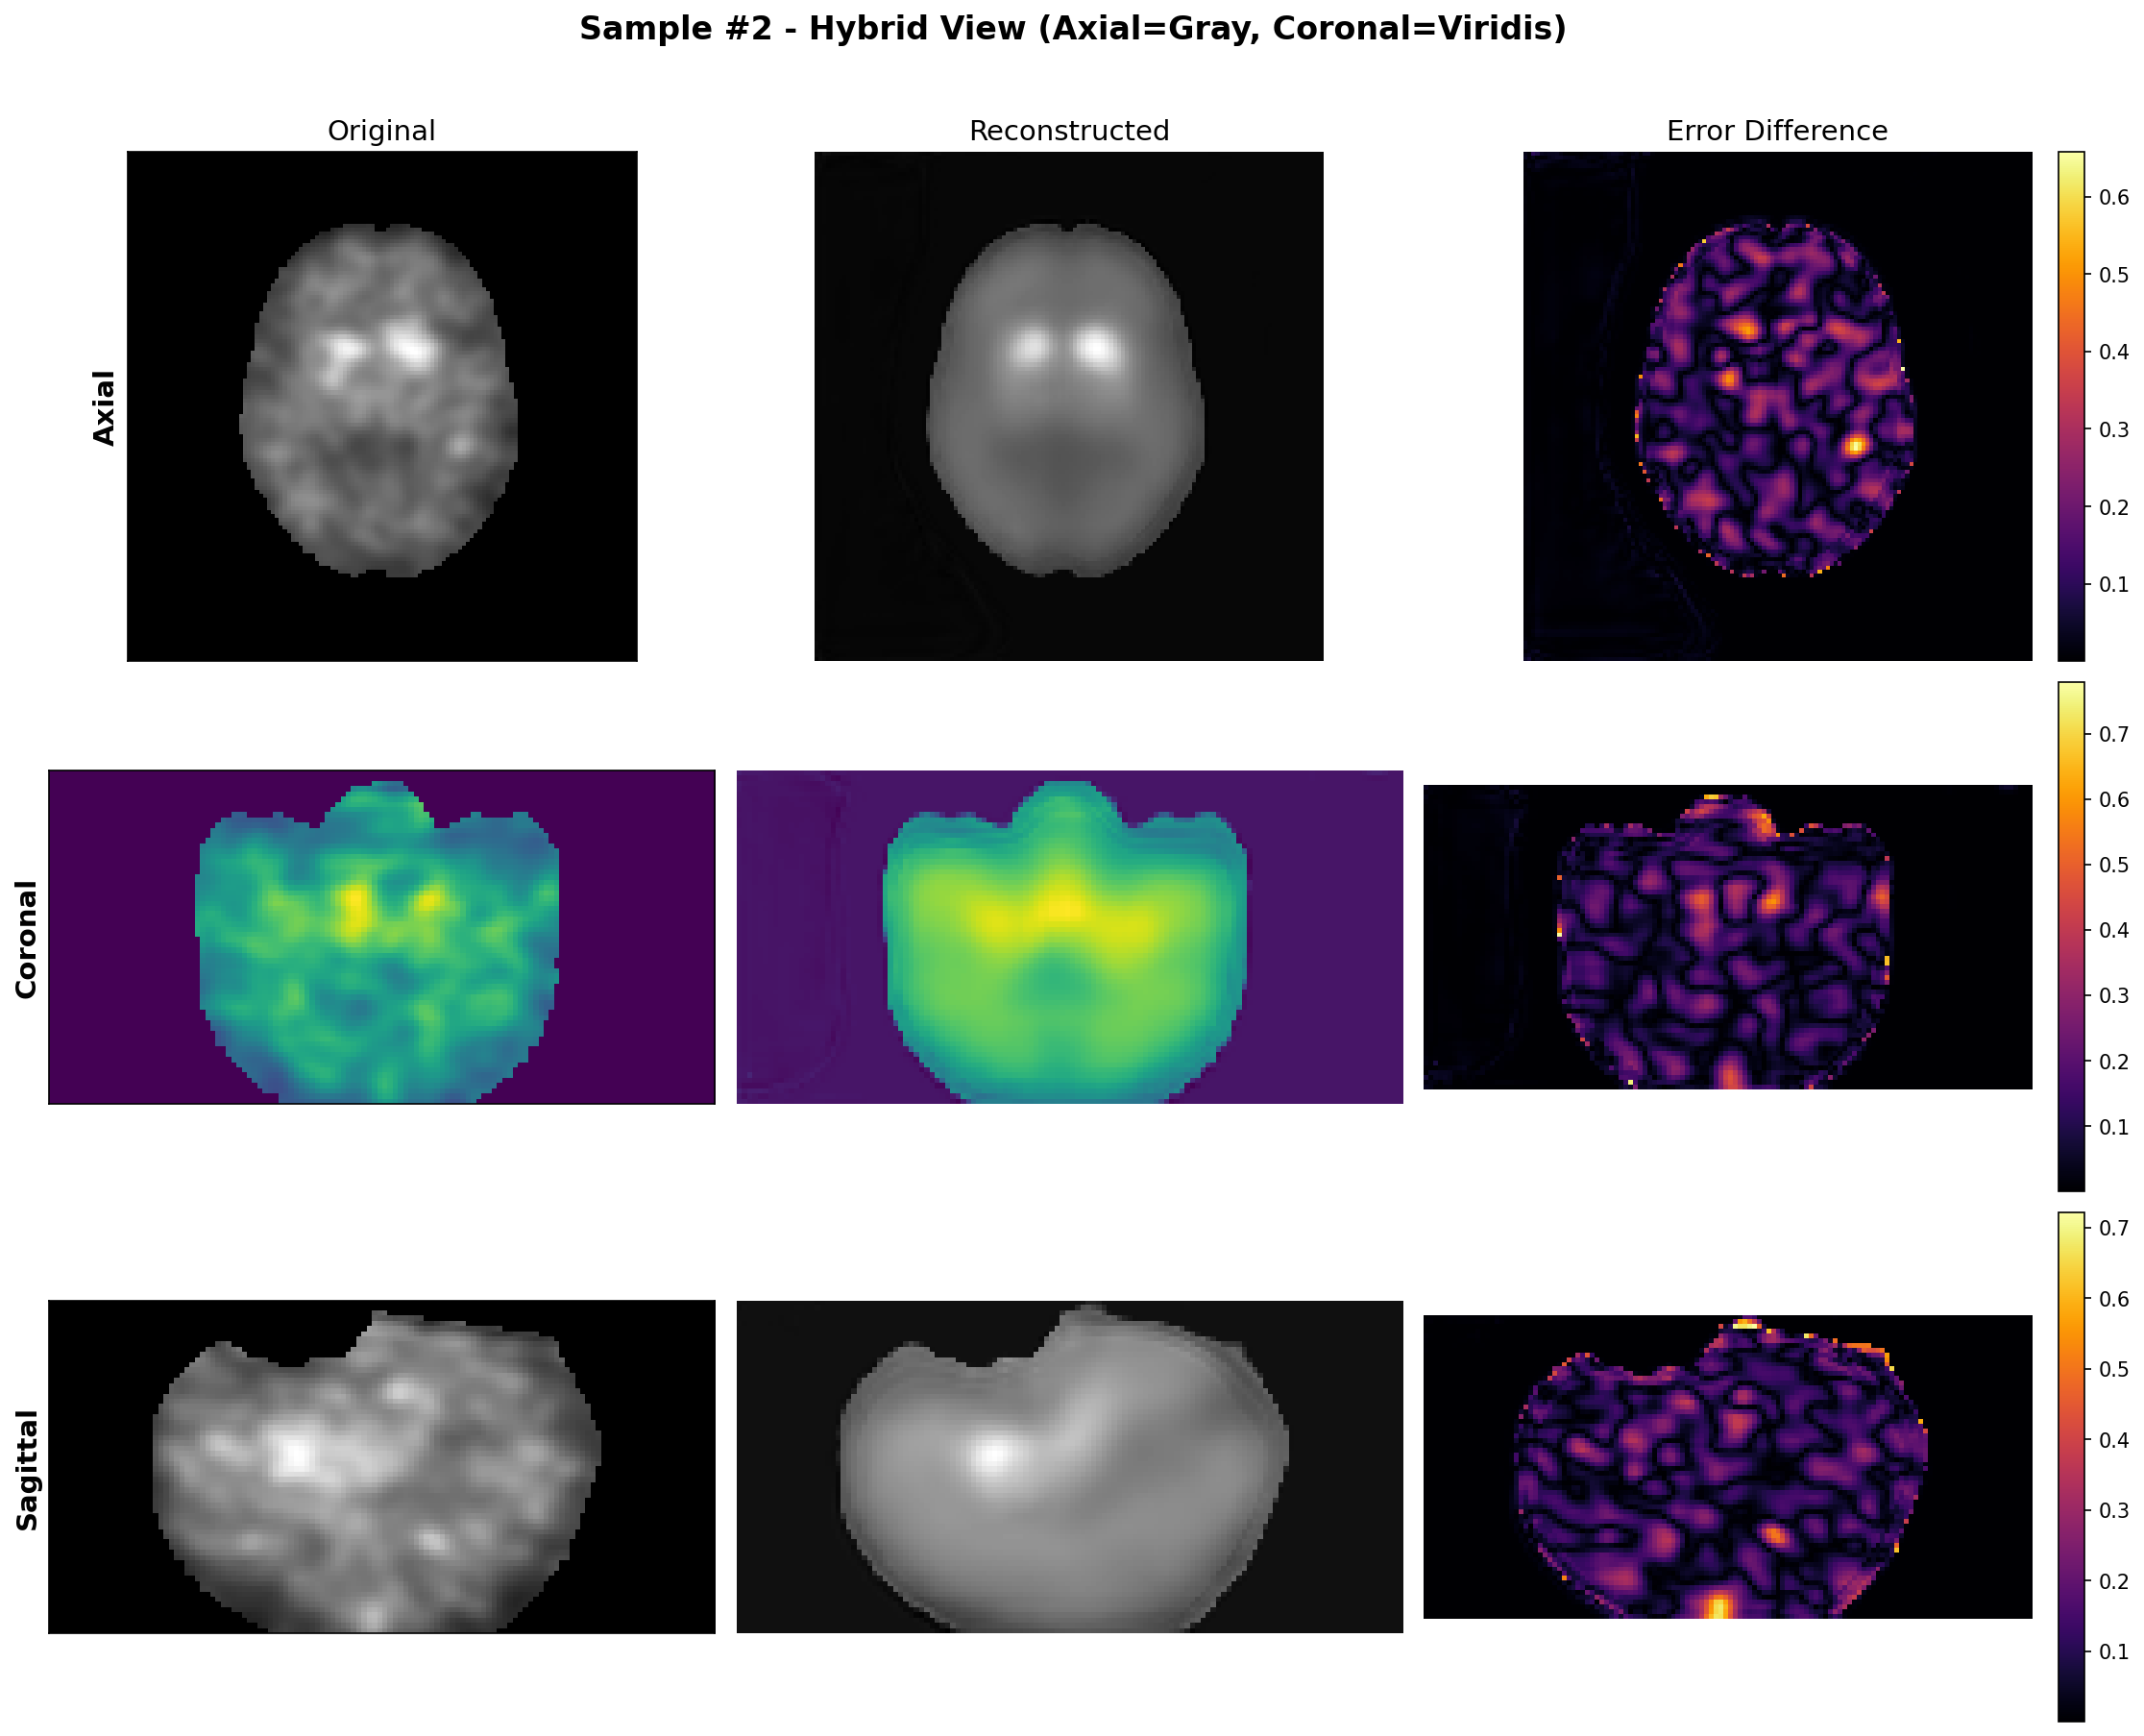

----------------------------------------------------------------------------------------------------


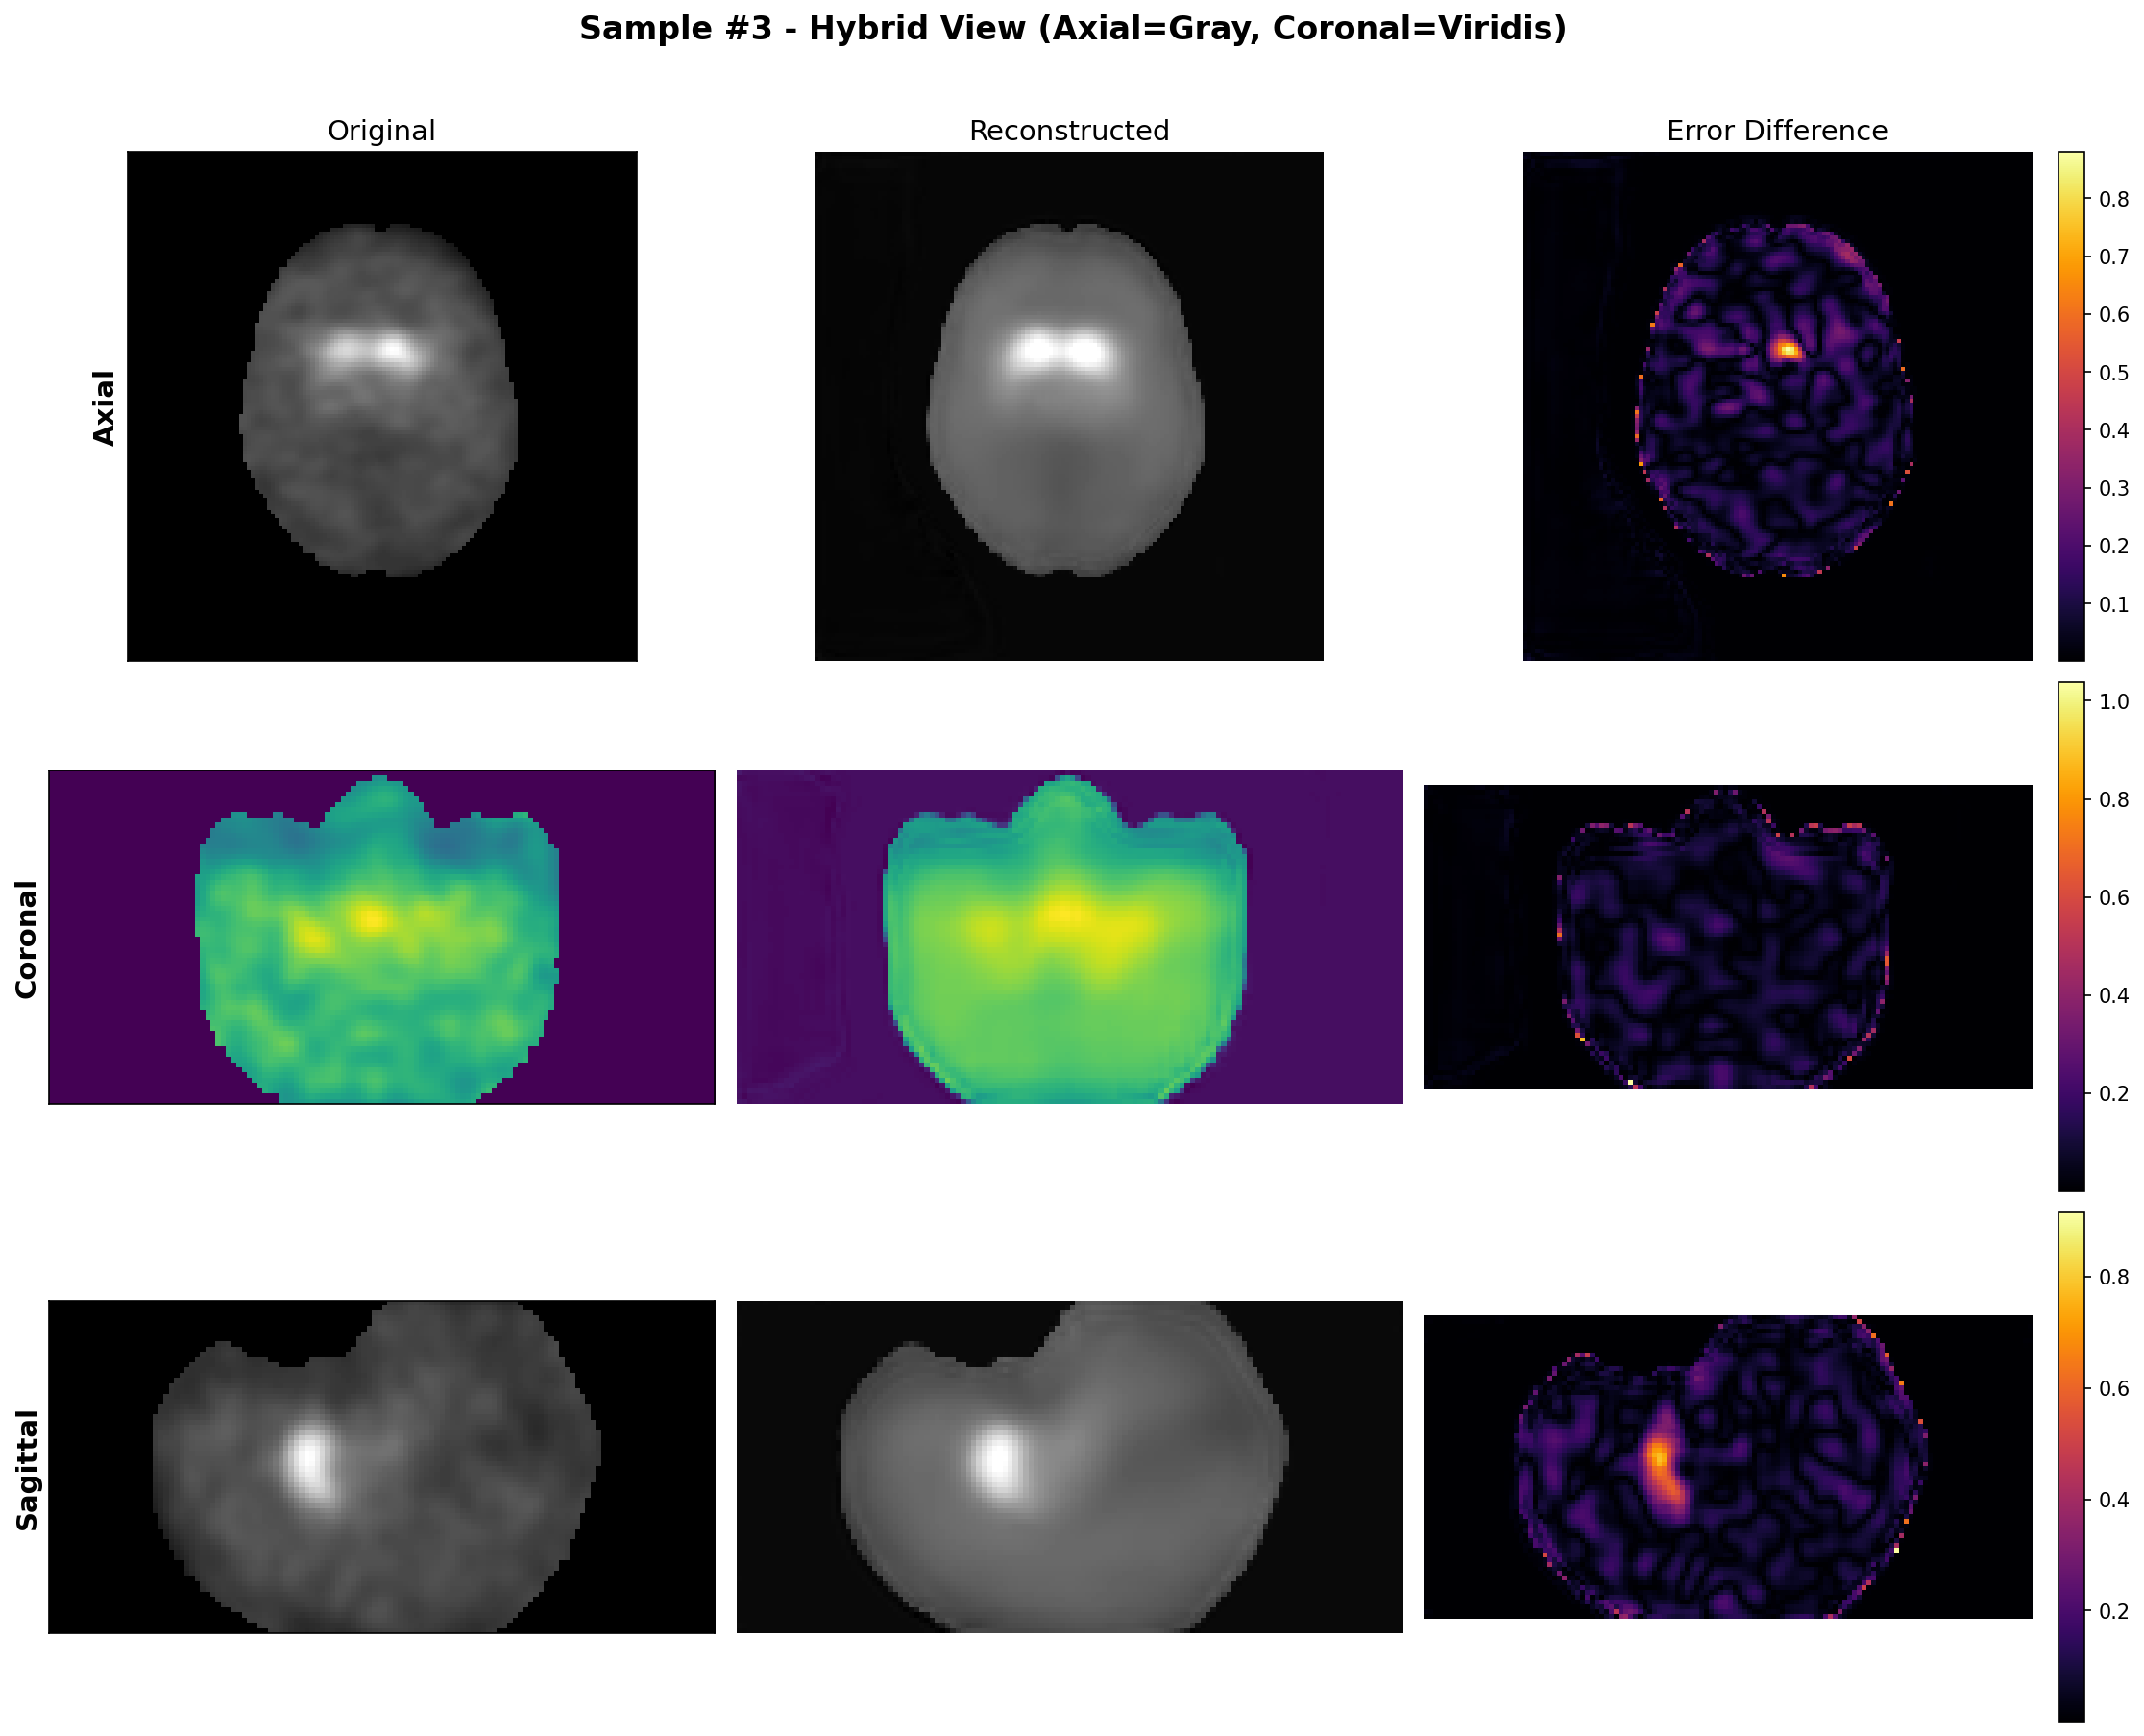

----------------------------------------------------------------------------------------------------


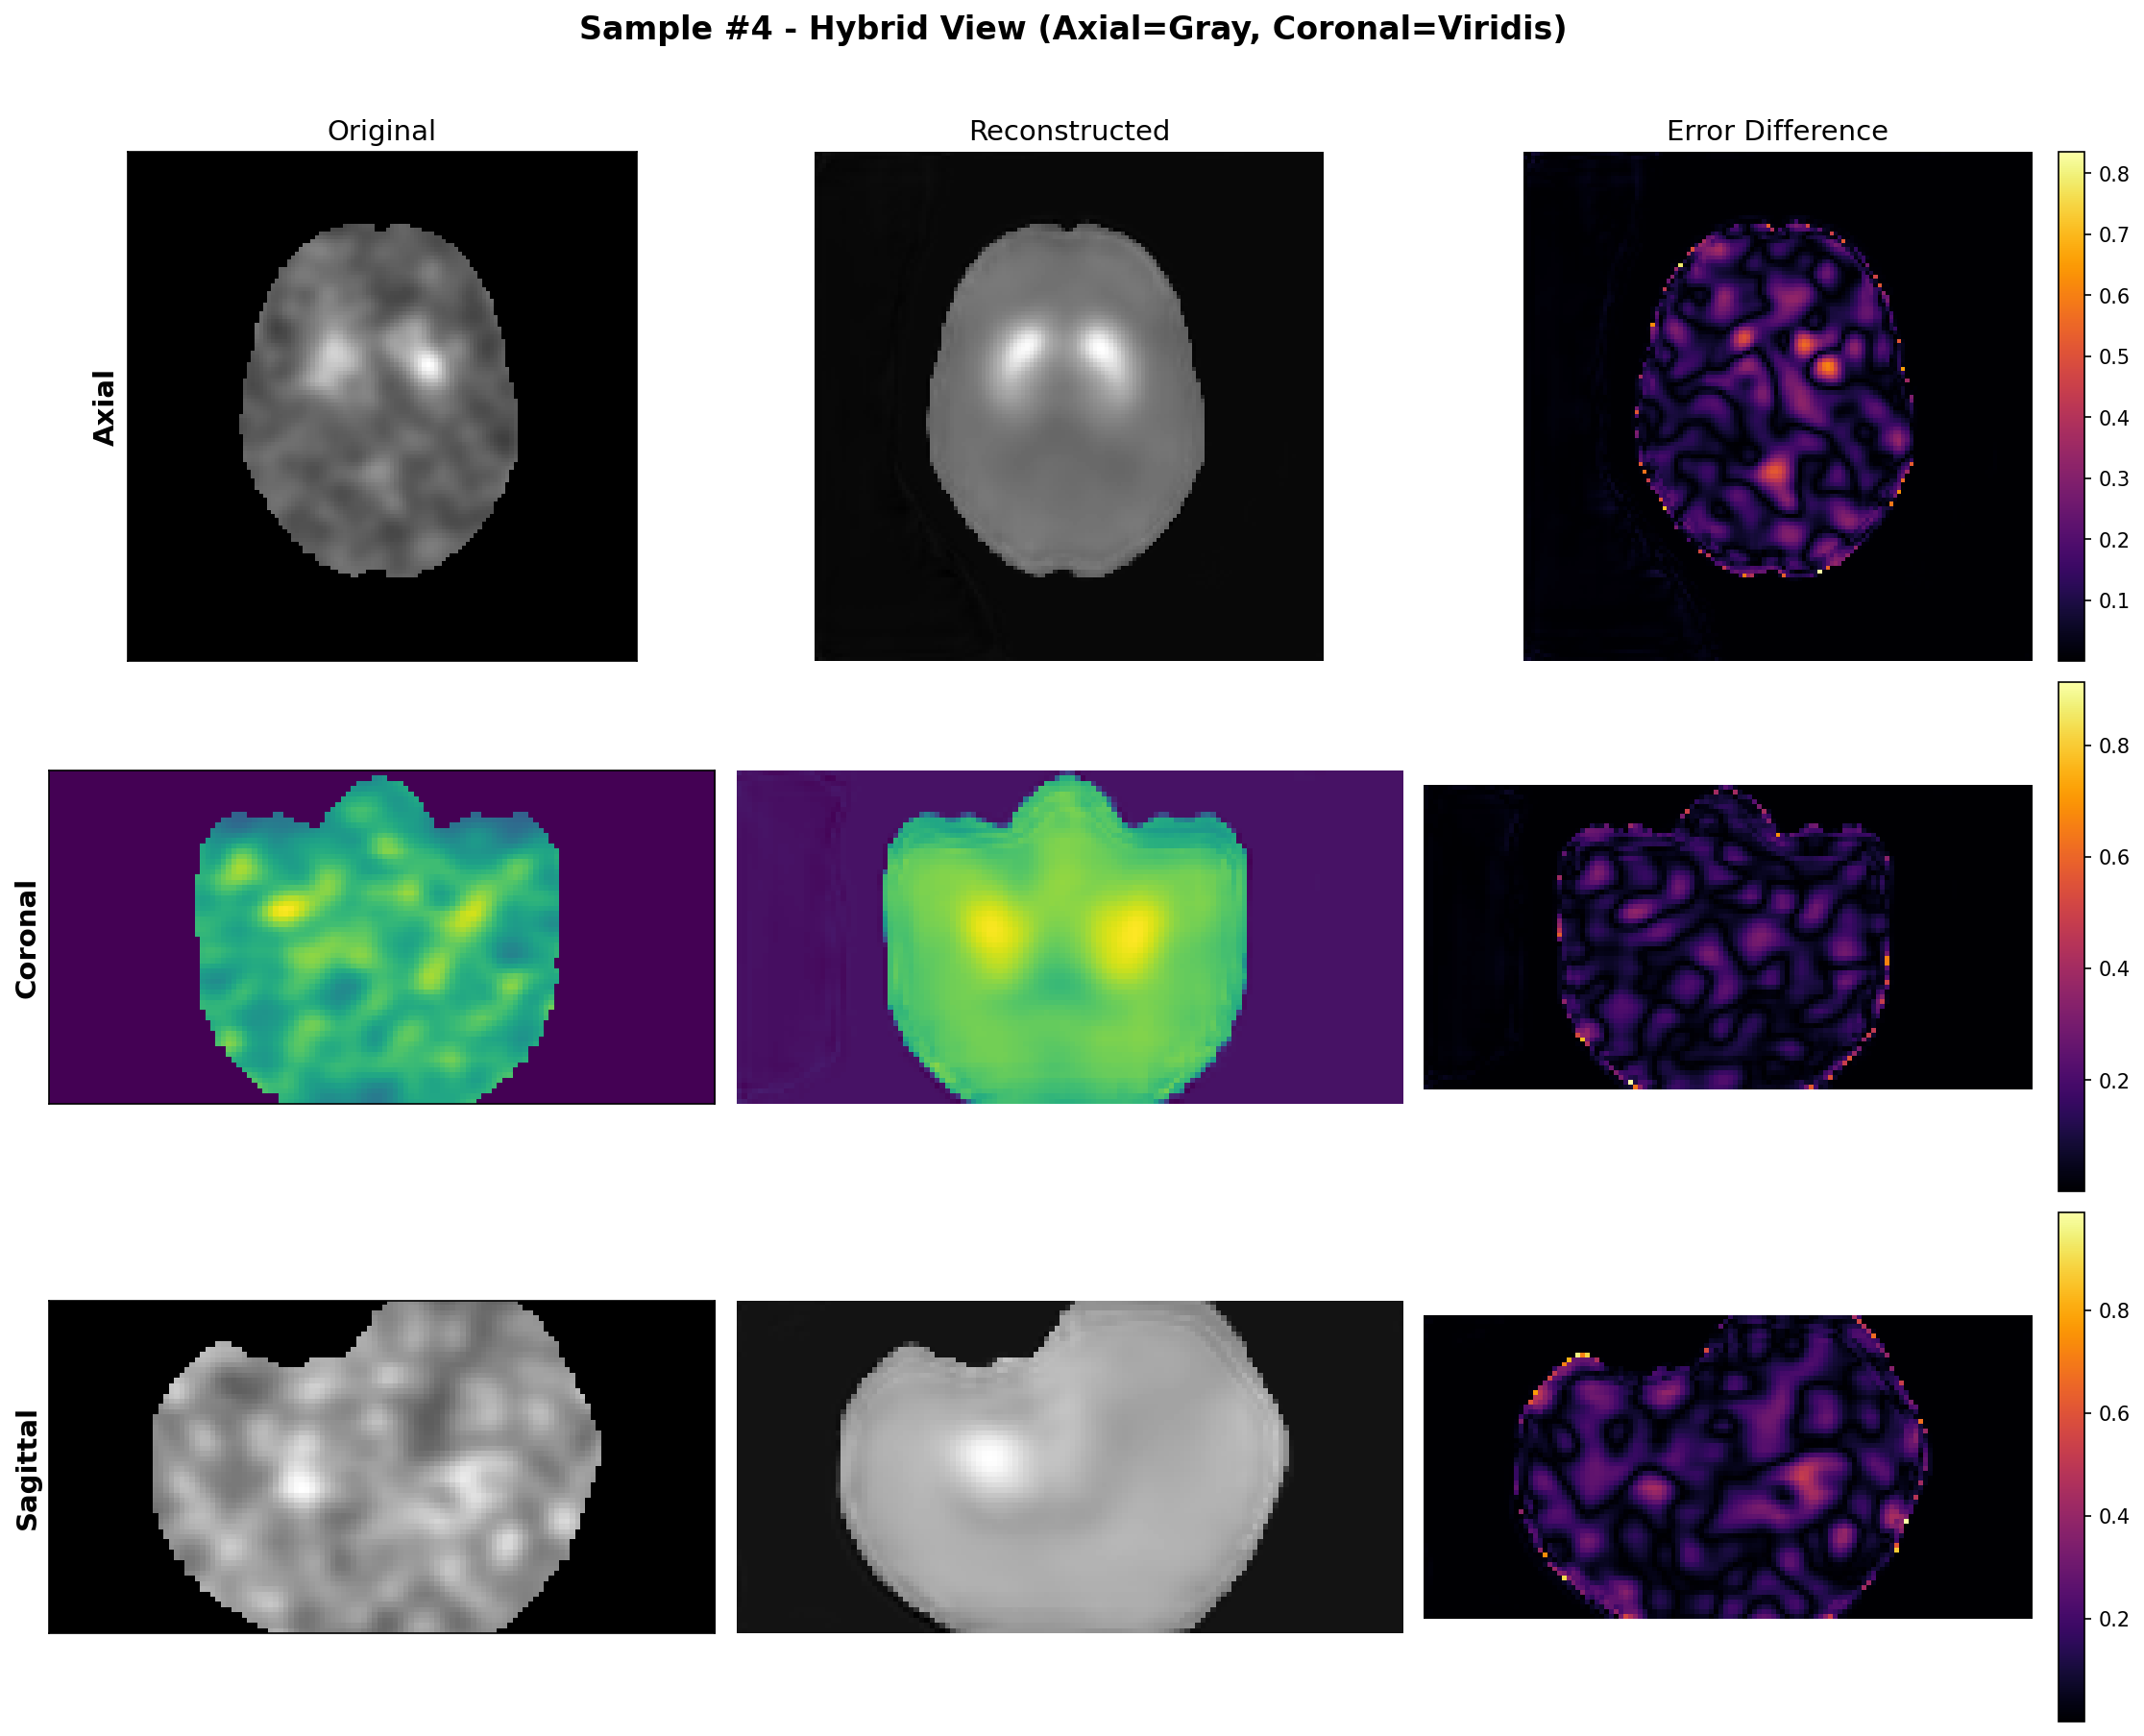

----------------------------------------------------------------------------------------------------


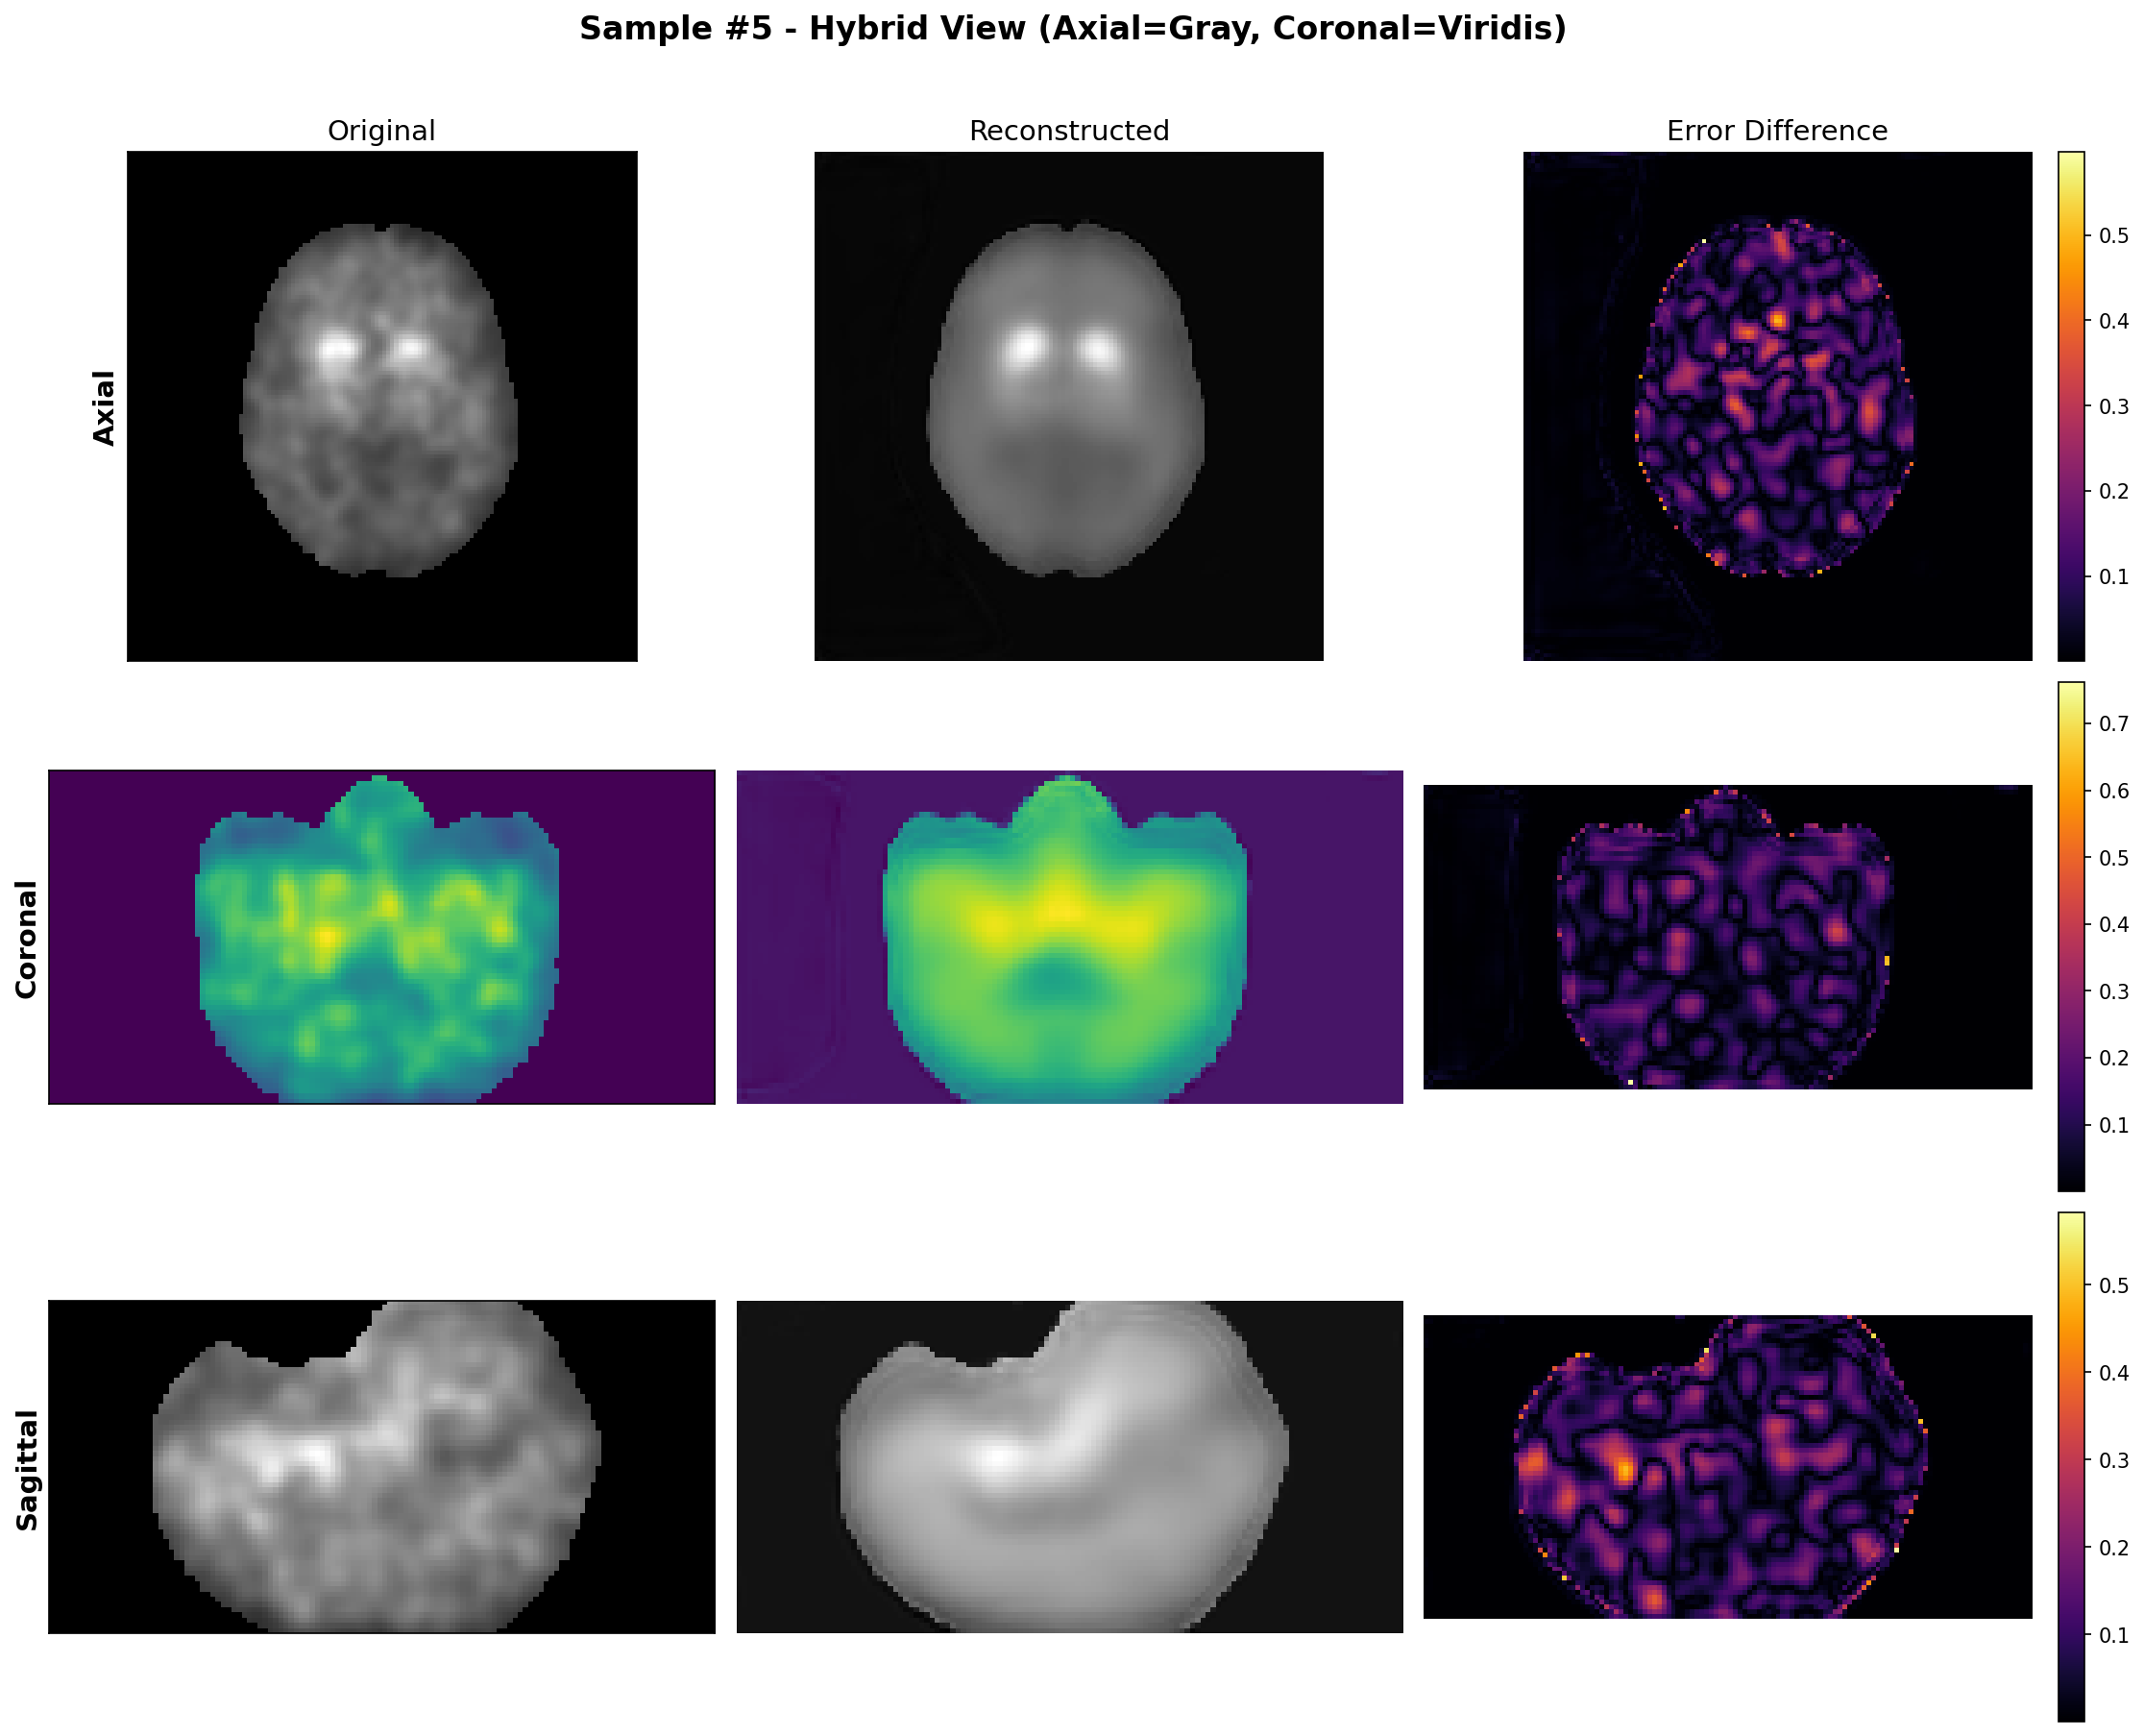

----------------------------------------------------------------------------------------------------


In [31]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Settings for large, clear plots
plt.rcParams['figure.figsize'] = [15, 12] 
plt.rcParams['figure.dpi'] = 150

# --- 1. Collect 5 Samples ---
num_samples_needed = 5
collected_images = []
iter_loader = iter(val_loader)

while len(collected_images) < num_samples_needed:
    try:
        batch = next(iter_loader)
        imgs = batch['volume'] if isinstance(batch, dict) else batch[0]
        collected_images.extend(imgs)
    except StopIteration:
        break 

# Convert to tensor
sample_data = torch.stack(collected_images[:num_samples_needed]).to(device)

# --- 2. Calculate Center Slices ---
_, _, D, H, W = sample_data.shape
mid_d, mid_h, mid_w = D // 2, H // 2, W // 2

# Define View Settings: (Name, Dimension, Slice Index, Colormap)
view_settings = [
    ('Axial',    0, mid_d, 'gray'),    # Axial stays GRAY
    ('Coronal',  1, mid_h, 'viridis'), # Coronal gets COLOR (Viridis)
    ('Sagittal', 2, mid_w, 'gray')     # Sagittal stays GRAY
]

# --- 3. Run Inference ---
best_model.eval()
with torch.no_grad():
    recons, _, _ = best_model(sample_data)

# --- 4. Visualization Loop ---
for i in range(num_samples_needed):
    
    # Extract data (CPU)
    orig_np = sample_data[i, 0].cpu().numpy()
    recon_np = recons[i, 0].cpu().numpy()
    
    # Create Figure
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    plt.suptitle(f"Sample #{i+1} - Hybrid View (Axial=Gray, Coronal=Viridis)", fontsize=16, weight='bold', y=1)
    
    for row_idx, (view_name, dim_idx, slice_idx, cmap_style) in enumerate(view_settings):
        
        # Helper: Extract Slices
        if dim_idx == 0: # Axial
            s_orig = orig_np[slice_idx, :, :]
            s_recon = recon_np[slice_idx, :, :]
        elif dim_idx == 1: # Coronal
            s_orig = orig_np[:, slice_idx, :]
            s_recon = recon_np[:, slice_idx, :]
        elif dim_idx == 2: # Sagittal
            s_orig = orig_np[:, :, slice_idx]
            s_recon = recon_np[:, :, slice_idx]

        # Calculate Error
        s_error = np.abs(s_orig - s_recon)
        
        # --- PLOT COLUMN 1: ORIGINAL ---
        # Note: No 'aspect=auto', so shape remains correct/normal
        axes[row_idx, 0].imshow(s_orig, cmap=cmap_style)
        axes[row_idx, 0].set_ylabel(f"{view_name}", fontsize=14, weight='bold')
        
        if row_idx == 0: axes[row_idx, 0].set_title("Original", fontsize=14)
        
        # Hide ticks
        axes[row_idx, 0].set_xticks([])
        axes[row_idx, 0].set_yticks([])

        # --- PLOT COLUMN 2: RECONSTRUCTED ---
        axes[row_idx, 1].imshow(s_recon, cmap=cmap_style)
        if row_idx == 0: axes[row_idx, 1].set_title("Reconstructed", fontsize=14)
        axes[row_idx, 1].axis('off')

        # --- PLOT COLUMN 3: ERROR ---
        # Error is always heatmap (Inferno) for visibility
        im = axes[row_idx, 2].imshow(s_error, cmap='inferno')
        if row_idx == 0: axes[row_idx, 2].set_title("Error Difference", fontsize=14)
        axes[row_idx, 2].axis('off')
        
        # Colorbar
        plt.colorbar(im, ax=axes[row_idx, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    print("-" * 100)